Gantt chart successfully saved as 'Traditional_Gantt_Chart.pdf'.


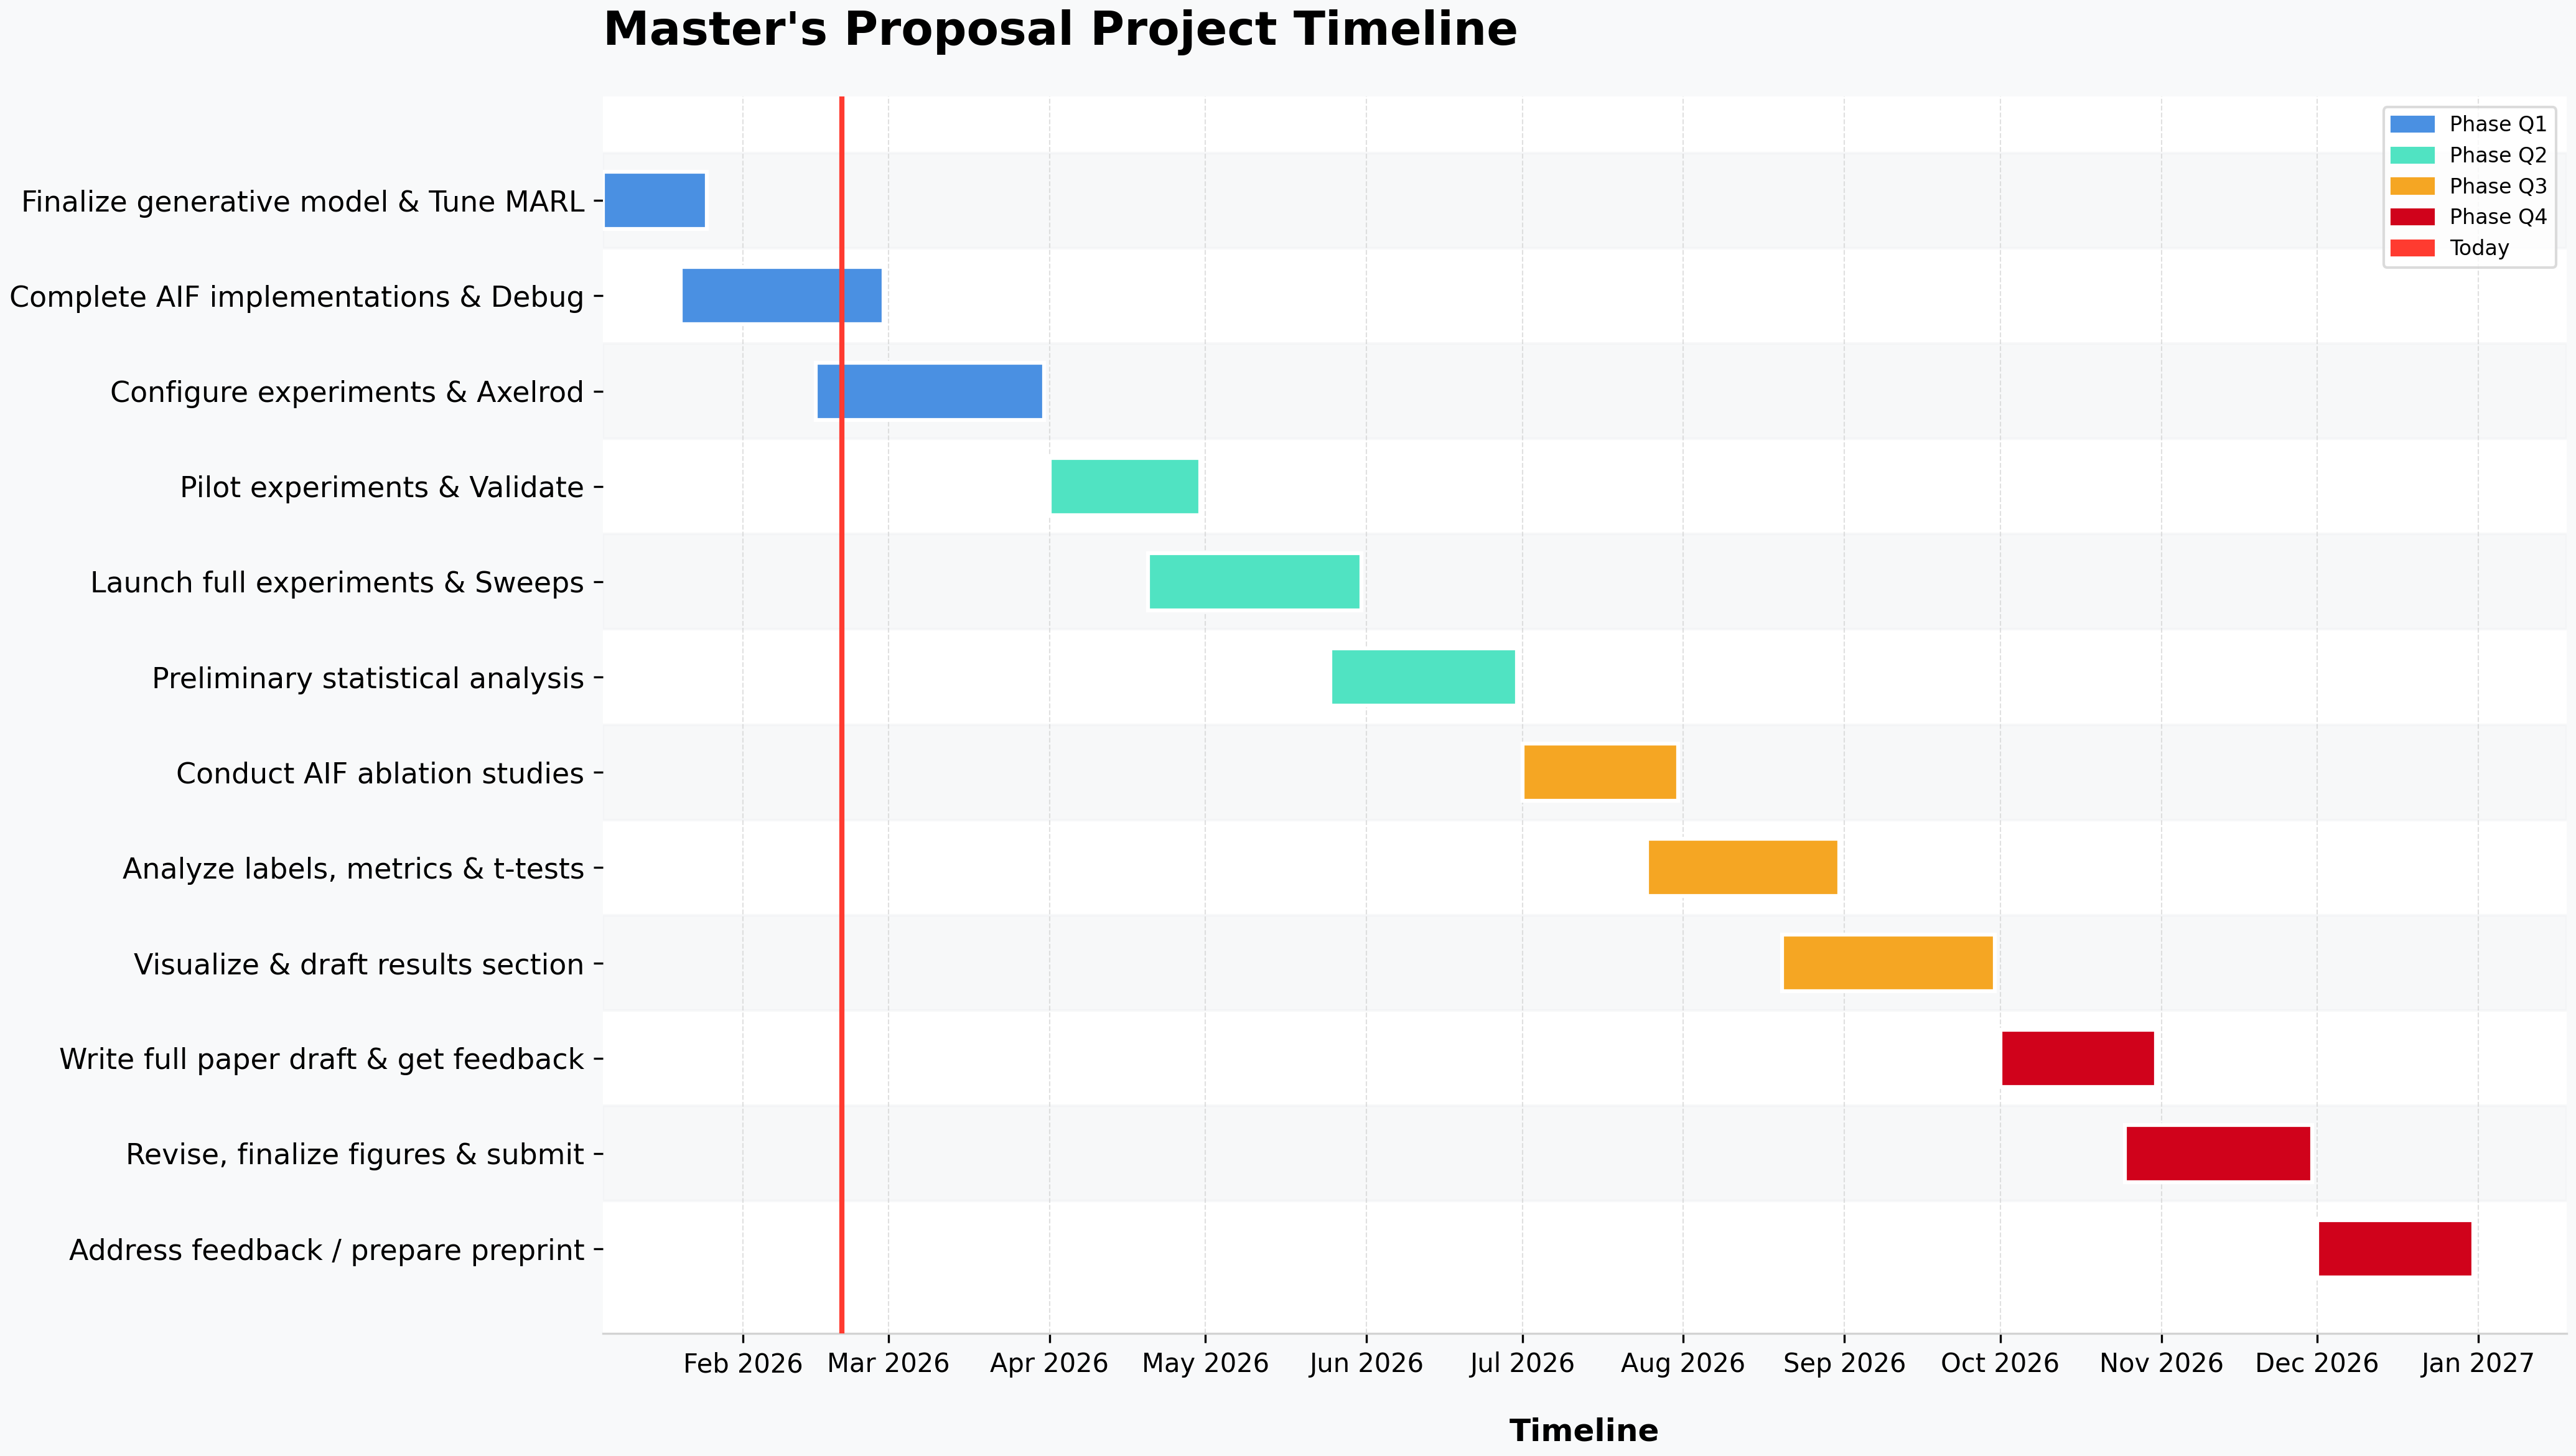

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from datetime import datetime

# 1. Define the timeline data with realistic overlaps and durations
data = [
    # Q1: Foundation & Implementation
    {"Task": "Finalize generative model & Tune MARL", "Start": "2026-01-05", "End": "2026-01-25", "Phase": "Q1"},
    {"Task": "Complete AIF implementations & Debug", "Start": "2026-01-20", "End": "2026-02-28", "Phase": "Q1"},
    {"Task": "Configure experiments & Axelrod", "Start": "2026-02-15", "End": "2026-03-31", "Phase": "Q1"},

    # Q2: Large-Scale Experimentation
    {"Task": "Pilot experiments & Validate", "Start": "2026-04-01", "End": "2026-04-30", "Phase": "Q2"},
    {"Task": "Launch full experiments & Sweeps", "Start": "2026-04-20", "End": "2026-05-31", "Phase": "Q2"},
    {"Task": "Preliminary statistical analysis", "Start": "2026-05-25", "End": "2026-06-30", "Phase": "Q2"},

    # Q3: Ablation & Deep Analysis
    {"Task": "Conduct AIF ablation studies", "Start": "2026-07-01", "End": "2026-07-31", "Phase": "Q3"},
    {"Task": "Analyze labels, metrics & t-tests", "Start": "2026-07-25", "End": "2026-08-31", "Phase": "Q3"},
    {"Task": "Visualize & draft results section", "Start": "2026-08-20", "End": "2026-09-30", "Phase": "Q3"},

    # Q4: Writing & Dissemination
    {"Task": "Write full paper draft & get feedback", "Start": "2026-10-01", "End": "2026-10-31", "Phase": "Q4"},
    {"Task": "Revise, finalize figures & submit", "Start": "2026-10-25", "End": "2026-11-30", "Phase": "Q4"},
    {"Task": "Address feedback / prepare preprint", "Start": "2026-12-01", "End": "2026-12-31", "Phase": "Q4"},
]

# 2. Process data into a DataFrame
df = pd.DataFrame(data)
df['Start'] = pd.to_datetime(df['Start'])
df['End'] = pd.to_datetime(df['End'])

# 3. Aesthetics & Colors
phases = df['Phase'].unique()
# Muted, professional color palette
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B'] 
color_map = {phase: colors[i % len(colors)] for i, phase in enumerate(phases)}
df['Color'] = df['Phase'].map(color_map)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#F8F9FA')
ax.set_facecolor('#FFFFFF')

# Draw alternating row backgrounds for readability
for i in range(len(df)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color='#F0F2F5', alpha=0.5, zorder=0)

# Plot traditional Gantt bars
for i, task in enumerate(df.itertuples()):
    start_num = mdates.date2num(task.Start)
    end_num = mdates.date2num(task.End)
    duration = end_num - start_num
    
    ax.barh(
        y=i, 
        width=duration, 
        left=start_num, 
        color=task.Color, 
        edgecolor='white',
        linewidth=1.5,
        height=0.6, # Thinner bars for a sleek look
        zorder=3
    )

# 5. Format the axes
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['Task'], fontsize=11)
ax.invert_yaxis() # First task at the top

# X-axis formatting (Months)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(fontsize=10, rotation=0, ha='center')

# Add subtle gridlines for the x-axis
ax.xaxis.grid(True, linestyle='--', color='#D3D3D3', alpha=0.7, zorder=1)

# 6. Add "Today" marker
current_date = pd.to_datetime('2026-02-20')
ax.axvline(x=mdates.date2num(current_date), color='#FF3B30', linestyle='-', linewidth=2, zorder=4, label='Today')

# 7. Add Title and Legend
ax.set_title("Master's Proposal Project Timeline", fontsize=18, fontweight='bold', pad=20, loc='left')
ax.set_xlabel('Timeline', fontsize=12, fontweight='bold', labelpad=15)

legend_patches = [mpatches.Patch(color=color_map[phase], label=f"Phase {phase}") for phase in phases]
legend_patches.append(mpatches.Patch(color='#FF3B30', label='Today'))
ax.legend(handles=legend_patches, loc='upper right', frameon=True, facecolor='white', edgecolor='#D3D3D3')

# 8. Clean up borders (spines)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#D3D3D3')

# 9. Save and display
plt.tight_layout()
plt.savefig("Traditional_Gantt_Chart.pdf", format="pdf", bbox_inches="tight")
print("Gantt chart successfully saved as 'Traditional_Gantt_Chart.pdf'.")

In [44]:
from __future__ import annotations

from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from experiments import (
    get_agent_dirs,
    get_player_names,
    load_selfplay_results,
    load_tournament_results,
    setup_publication_style,
)

In [45]:
# === Configuration ===
# Choose game: "pd" (IPD), "chicken", or "stag"
GAME: Literal["pd", "chicken", "stag"] = "pd"

# Proposal plots use two noise levels (as requested)
NOISE_LEVELS: list[float] = [0.0, 0.05]

# Data roots (relative to this notebook: experiments/other/)
TOURNAMENT_ROOT = Path("../../results/main") / GAME
SELFPLAY_ROOT = Path("../../results/sp") / GAME

# Output directory for proposal figures
OUTPUT_DIR = (Path("../../results/main") / GAME / "plots" / "proposal")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Bar order / modes
MODES: list[Literal["static", "adaptive", "crossplay", "selfplay"]] = [
    "static",
    "adaptive",
    "crossplay",
    "selfplay",
]
MODE_LABEL = {
    "static": "Static",
    "adaptive": "Adaptive",
    "crossplay": "Crossplay",
    "selfplay": "Selfplay",
}

# Agent index groups
GROUPS: dict[str, list[int]] = {
    "AIF": [9],
    "QL": [0],
    "BQL": [1],
    "DynaQ": [5],
    "PSRL": [6],
    "GTFT": [3],
    "CTFT": [4],
    "DBS": [2],
    "EpsAIF": [11],
}

# Ablations (variants compared against base 8)
# Focal/base agent: 8
# 7 = Epistemic
# 9 = Noise+Epistemic
# 10 = Noise
# 11 = Epsilon-Greedy
ABLATIONS: list[tuple[str, int, int]] = [
    ("Epistemic", 7, 8),
    ("Noise+Epistemic", 9, 8),
    ("Noise", 10, 8),
    ("Epsilon-Greedy", 11, 8),
]

# Convenience paths for tournament pools
POOL_DIR_BY_MODE = {
    "static": TOURNAMENT_ROOT / "static",
    "adaptive": TOURNAMENT_ROOT / "learning",
}

# Selfplay directory
SP_DIR = SELFPLAY_ROOT

print(f"GAME={GAME}")
print(f"TOURNAMENT_ROOT={TOURNAMENT_ROOT}")
print(f"SELFPLAY_ROOT={SELFPLAY_ROOT}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")


GAME=pd
TOURNAMENT_ROOT=../../results/main/pd
SELFPLAY_ROOT=../../results/sp/pd
OUTPUT_DIR=../../results/main/pd/plots/proposal


In [46]:
# === Shared plot style ===
setup_publication_style(use_latex=False, font_size=10)

# Bar colors (bars now represent categories / ablations)
BESTOF_BAR_COLORS = {
    "AIF": "#4C78A8",       # blue
    "QL": "#F58518",        # orange
    "BQL": "#E45756",       # red
    "DynaQ": "#EECA3B",     # yellow
    "PSRL": "#FF9DA6",      # pink
    "GTFT": "#54A24B",      # green
    "CTFT": "#88D27A",      # light green
    "DBS": "#72B7B2",       # teal
    "EpsAIF": "#B279A2",    # purple
}

ABLATION_BAR_COLORS = {
    "Epistemic": "#4C78A8",
    "Noise+Epistemic": "#B279A2",
    "Noise": "#E45756",
    "Epsilon-Greedy": "#72B7B2",
}

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [47]:
# === Helpers (loading, CI, best-of selection, plotting) ===

def _t_ci95(arr: np.ndarray, *, clip01: bool = False) -> tuple[float, float, float, int]:
    """Return (mean, ci_lower, ci_upper, n) using a 95% t-interval."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    n = int(arr.size)
    if n == 0:
        return (np.nan, np.nan, np.nan, 0)

    mean = float(np.mean(arr))

    if n == 1:
        lo = hi = mean
    else:
        std = float(np.std(arr, ddof=1))
        if not np.isfinite(std) or std <= 0:
            lo = hi = mean
        else:
            ci = stats.t.interval(0.95, n - 1, loc=mean, scale=std / np.sqrt(n))
            lo, hi = float(ci[0]), float(ci[1])
            if not np.isfinite(lo) or not np.isfinite(hi):
                lo = hi = mean

    if clip01:
        lo = max(0.0, lo)
        hi = min(1.0, hi)
    return (mean, lo, hi, n)


def _find_agent_dir(pool_dir: Path, agent_idx: int) -> str:
    matches = sorted([p.name for p in pool_dir.glob(f"{agent_idx}_*") if p.is_dir()])
    if not matches:
        raise FileNotFoundError(f"No agent dir for idx={agent_idx} in {pool_dir}")
    return matches[0]


def _tournament_rep_values(
    pool_dir: Path,
    agent_idx: int,
    noise: float,
    metric: Literal["score", "cc_rate"],
) -> dict[int, float]:
    agent_dir = _find_agent_dir(pool_dir, agent_idx)
    df = load_tournament_results(pool_dir, agent_dir, noise)
    if df.empty:
        return {}

    agent_df = df[df["Player index"] == 0]
    out: dict[int, float] = {}

    for rep in sorted(agent_df["repetition"].unique()):
        rep_df = agent_df[agent_df["repetition"] == rep]
        if rep_df.empty:
            continue

        if metric == "score":
            out[int(rep)] = float(rep_df["Score"].mean())
        else:
            turns = float(rep_df["Turns"].sum())
            if turns <= 0:
                continue
            cc = float(rep_df["CC count"].sum())
            out[int(rep)] = cc / turns

    return out


def _tournament_agg(
    pool_dir: Path,
    noise: float,
    metric: Literal["score", "cc_rate"],
) -> pd.DataFrame:
    rows: list[dict] = []
    for dir_name, _display in get_agent_dirs(pool_dir):
        try:
            agent_idx = int(dir_name.split("_")[0])
        except Exception:
            continue

        rep_map = _tournament_rep_values(pool_dir, agent_idx, noise, metric)
        arr = np.array(list(rep_map.values()), dtype=float)
        mean, lo, hi, n = _t_ci95(arr, clip01=(metric == "cc_rate"))
        rows.append(
            {
                "agent_idx": agent_idx,
                "mean": mean,
                "ci_lower": lo,
                "ci_upper": hi,
                "n": n,
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values("agent_idx").reset_index(drop=True)


def _selfplay_rep_values(
    sp_dir: Path,
    agent_idx: int,
    noise: float,
    metric: Literal["score", "cc_rate"],
    *,
    diagonal: bool,
) -> dict[int, float]:
    df = load_selfplay_results(sp_dir, noise)
    if df.empty:
        return {}

    player_names = get_player_names(sp_dir)
    if agent_idx < 0 or agent_idx >= len(player_names):
        raise IndexError(f"agent_idx={agent_idx} out of range for selfplay players={len(player_names)}")

    player = player_names[agent_idx]

    # Filter to this player's perspective
    pdf = df[df["Player name"] == player]
    if pdf.empty:
        return {}

    out: dict[int, float] = {}
    for rep in sorted(pdf["repetition"].unique()):
        rep_df = pdf[pdf["repetition"] == rep]
        if rep_df.empty:
            continue

        if diagonal:
            rep_df = rep_df[rep_df["Opponent name"] == player]
        else:
            rep_df = rep_df[rep_df["Opponent name"] != player]

        if rep_df.empty:
            continue

        if metric == "score":
            out[int(rep)] = float(rep_df["Score"].mean())
        else:
            turns = float(rep_df["Turns"].sum())
            if turns <= 0:
                continue
            cc = float(rep_df["CC count"].sum())
            out[int(rep)] = cc / turns

    return out


def _selfplay_agg(
    sp_dir: Path,
    noise: float,
    metric: Literal["score", "cc_rate"],
    *,
    diagonal: bool,
) -> pd.DataFrame:
    player_names = get_player_names(sp_dir)
    rows: list[dict] = []
    for agent_idx in range(len(player_names)):
        rep_map = _selfplay_rep_values(sp_dir, agent_idx, noise, metric, diagonal=diagonal)
        arr = np.array(list(rep_map.values()), dtype=float)
        mean, lo, hi, n = _t_ci95(arr, clip01=(metric == "cc_rate"))
        rows.append(
            {
                "agent_idx": agent_idx,
                "mean": mean,
                "ci_lower": lo,
                "ci_upper": hi,
                "n": n,
            }
        )

    df = pd.DataFrame(rows)
    return df.sort_values("agent_idx").reset_index(drop=True)


def _best_in_group(agg: pd.DataFrame, agent_indices: list[int]) -> dict:
    sub = agg[agg["agent_idx"].isin(agent_indices)].dropna(subset=["mean"])
    if sub.empty:
        return {"agent_idx": None, "mean": np.nan, "ci_lower": np.nan, "ci_upper": np.nan, "n": 0}
    best_row = sub.sort_values("mean", ascending=False).iloc[0]
    return best_row.to_dict()


def _paired_delta_ci(
    rep_a: dict[int, float],
    rep_b: dict[int, float],
    *,
    clip01: bool = False,
) -> tuple[float, float, float, int]:
    common = sorted(set(rep_a.keys()) & set(rep_b.keys()))
    if not common:
        return (np.nan, np.nan, np.nan, 0)
    deltas = np.array([rep_a[r] - rep_b[r] for r in common], dtype=float)
    return _t_ci95(deltas, clip01=clip01)


def _paired_percent_change_ci(
    rep_variant: dict[int, float],
    rep_base: dict[int, float],
) -> tuple[float, float, float, int]:
    """Relative % change per repetition: ((variant - base) / base) * 100.

    Use for metrics with a meaningful non-zero baseline (e.g. score).
    Repetitions with (near-)zero or non-finite baseline are skipped.
    """
    common = sorted(set(rep_variant.keys()) & set(rep_base.keys()))
    if not common:
        return (np.nan, np.nan, np.nan, 0)

    pct: list[float] = []
    for r in common:
        base = float(rep_base[r])
        var = float(rep_variant[r])
        if not np.isfinite(base) or abs(base) < 1e-12:
            continue
        if not np.isfinite(var):
            continue
        pct.append(((var - base) / base) * 100.0)

    if not pct:
        return (np.nan, np.nan, np.nan, 0)

    return _t_ci95(np.array(pct, dtype=float), clip01=False)


def _paired_pp_change_ci(
    rep_variant: dict[int, float],
    rep_base: dict[int, float],
) -> tuple[float, float, float, int]:
    """Percentage-point change per repetition: (variant - base) * 100.

    Use for metrics already on a [0,1] scale (e.g. cc_rate) where dividing
    by a near-zero baseline would produce meaninglessly large % changes.
    """
    common = sorted(set(rep_variant.keys()) & set(rep_base.keys()))
    if not common:
        return (np.nan, np.nan, np.nan, 0)

    pp: list[float] = []
    for r in common:
        base = float(rep_base[r])
        var = float(rep_variant[r])
        if not np.isfinite(base) or not np.isfinite(var):
            continue
        pp.append((var - base) * 100.0)

    if not pp:
        return (np.nan, np.nan, np.nan, 0)

    return _t_ci95(np.array(pp, dtype=float), clip01=False)


def _plot_grouped_bars(
    *,
    group_labels: list[str],
    bar_labels: list[str],
    values: np.ndarray,
    ci_lowers: np.ndarray,
    ci_uppers: np.ndarray,
    bar_colors: dict[str, str] | None,
    ylabel: str,
    title: str,
    save_stem: Path,
    ylim: tuple[float, float] | None = None,
):
    """Grouped bars: shape(values) == (n_groups, n_bars).

    Bars with missing values (NaN/inf) are skipped.
    """
    n_groups = len(group_labels)
    n_bars = len(bar_labels)

    x = np.arange(n_groups, dtype=float)
    width = min(0.8 / max(1, n_bars), 0.25)
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2.0) * width

    fig, ax = plt.subplots(figsize=(10, 4.2))

    bar_labeled: set[str] = set()

    for j, bar_label in enumerate(bar_labels):
        for i in range(n_groups):
            y = float(values[i, j])
            lo = float(ci_lowers[i, j])
            hi = float(ci_uppers[i, j])

            if not np.isfinite(y):
                continue

            if np.isfinite(lo) and np.isfinite(hi):
                yerr_lower = max(0.0, y - lo)
                yerr_upper = max(0.0, hi - y)
                yerr = np.array([[yerr_lower], [yerr_upper]])
            else:
                yerr = None

            label = bar_label if bar_label not in bar_labeled else None
            if label is not None:
                bar_labeled.add(bar_label)

            color = (bar_colors or {}).get(bar_label, None)

            ax.bar(
                x[i] + offsets[j],
                y,
                width=width,
                label=label,
                color=color,
                yerr=yerr,
                capsize=2,
                linewidth=0.6,
                edgecolor="black",
                alpha=0.95,
                error_kw={"elinewidth": 0.8, "capthick": 0.8},
            )

    ax.set_xticks(x)
    ax.set_xticklabels(group_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            ncol=min(4, len(handles)),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.18),
            frameon=False,
        )

    if ylim is not None:
        ax.set_ylim(*ylim)

    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(Path(str(save_stem) + f".{ext}"))

    plt.show()


def plot_bestof(
    *,
    noise: float,
    metric: Literal["score", "cc_rate"],
):
    if metric == "score":
        ylabel = "Mean score"
        metric_label = "Score"
        ylim = None
    else:
        ylabel = "Cooperation rate (CC)"
        metric_label = "CC rate"
        ylim = (0.0, 1.0)

    mode_aggs: dict[str, pd.DataFrame] = {}

    # Tournament modes
    for mode in ["static", "adaptive"]:
        pool_dir = POOL_DIR_BY_MODE[mode]
        if pool_dir.exists():
            mode_aggs[mode] = _tournament_agg(pool_dir, noise, metric)
        else:
            mode_aggs[mode] = pd.DataFrame()

    # Selfplay-derived modes
    if SP_DIR.exists():
        mode_aggs["crossplay"] = _selfplay_agg(SP_DIR, noise, metric, diagonal=False)
        mode_aggs["selfplay"] = _selfplay_agg(SP_DIR, noise, metric, diagonal=True)
    else:
        mode_aggs["crossplay"] = pd.DataFrame()
        mode_aggs["selfplay"] = pd.DataFrame()

    # Build idx → dir-name lookup (for printing winner names)
    idx_to_dir: dict[str, dict[int, str]] = {}
    for _m in ["static", "adaptive"]:
        _pool = POOL_DIR_BY_MODE[_m]
        if _pool.exists():
            idx_to_dir[_m] = {int(d.split("_")[0]): d for d, _ in get_agent_dirs(_pool)}
    sp_player_names = get_player_names(SP_DIR) if SP_DIR.exists() else []

    # Display labels for the legend (separate from internal GROUPS keys)
    BAR_DISPLAY_LABEL = {
        "AIF": "Full AIF",
        "QL": "QL",
        "BQL": "BQL",
        "DynaQ": "DynaQ",
        "PSRL": "PSRL",
        "GTFT": "GTFT",
        "CTFT": "CTFT",
        "DBS": "DBS",
        "EpsAIF": "Eps-Greedy AIF",
    }

    group_labels = [MODE_LABEL[m] for m in MODES]
    group_keys = list(GROUPS.keys())           # internal keys: AIF/MARL/Heuristic
    bar_labels = [BAR_DISPLAY_LABEL[k] for k in group_keys]  # legend labels

    # Colors keyed by display label
    bar_colors_display = {BAR_DISPLAY_LABEL[k]: v for k, v in BESTOF_BAR_COLORS.items()}

    values = np.full((len(MODES), len(group_keys)), np.nan)
    lo = np.full_like(values, np.nan, dtype=float)
    hi = np.full_like(values, np.nan, dtype=float)
    winner_names: dict[tuple[int, int], str] = {}

    for i_mode, mode in enumerate(MODES):
        agg = mode_aggs.get(mode, pd.DataFrame())
        if agg.empty:
            continue

        for j_bar, group_key in enumerate(group_keys):
            best = _best_in_group(agg, GROUPS[group_key])
            values[i_mode, j_bar] = best["mean"]
            lo[i_mode, j_bar] = best["ci_lower"]
            hi[i_mode, j_bar] = best["ci_upper"]

            w_idx = best.get("agent_idx")
            if w_idx is not None and np.isfinite(float(w_idx)):
                w_idx = int(w_idx)
                if mode in ["static", "adaptive"]:
                    name = idx_to_dir.get(mode, {}).get(w_idx, str(w_idx))
                else:
                    name = sp_player_names[w_idx] if w_idx < len(sp_player_names) else str(w_idx)
                winner_names[(i_mode, j_bar)] = name

    # --- print winner summary table ---
    print(f"\n{'='*70}")
    print(f"Best-of winners  |  {GAME.upper()}  |  {metric_label}  |  noise={noise:.2f}")
    print(f"{'='*70}")
    col_w = 28
    mode_w = 10
    header = f"{'Mode':<{mode_w}}" + "".join(f"  {k:<{col_w}}" for k in group_keys)
    print(header)
    print("-" * len(header))
    for i_mode, mode in enumerate(MODES):
        row = f"{MODE_LABEL[mode]:<{mode_w}}"
        for j_bar in range(len(group_keys)):
            name = winner_names.get((i_mode, j_bar), "—")
            val = values[i_mode, j_bar]
            cell = f"{name}  ({val:.4f})" if np.isfinite(val) else "—"
            row += f"  {cell:<{col_w}}"
        print(row)
    print()

    title = f"{GAME.upper()} – Agent {metric_label} – noise={noise:.2f}"
    save_stem = OUTPUT_DIR / f"bestof_{metric}_{noise:.2f}".replace(".", "p")

    _plot_grouped_bars(
        group_labels=group_labels,
        bar_labels=bar_labels,
        values=values,
        ci_lowers=lo,
        ci_uppers=hi,
        bar_colors=bar_colors_display,
        ylabel=ylabel,
        title=title,
        save_stem=save_stem,
        ylim=ylim,
    )


def plot_ablation_deltas(
    *,
    noise: float,
    metric: Literal["score", "cc_rate"],
):
    if metric == "score":
        # Score: relative % change — denominator (mean score) is always large
        ylabel = "% change in mean score vs baseline"
        metric_label = "Score"
        _ci_fn = _paired_percent_change_ci
    else:
        # CC rate is [0,1] — use percentage-point change to avoid near-zero
        # denominator blowup (e.g. agent 8 defects against itself → CC≈0)
        ylabel = "Change in CC rate vs baseline [pp]"
        metric_label = "CC rate"
        _ci_fn = _paired_pp_change_ci

    group_labels = [MODE_LABEL[m] for m in MODES]
    bar_labels = [name for (name, _a, _b) in ABLATIONS]

    values = np.full((len(MODES), len(ABLATIONS)), np.nan)
    lo = np.full_like(values, np.nan, dtype=float)
    hi = np.full_like(values, np.nan, dtype=float)

    for i_mode, mode in enumerate(MODES):
        if mode in ["static", "adaptive"]:
            pool_dir = POOL_DIR_BY_MODE[mode]
            if not pool_dir.exists():
                continue
            for j_bar, (_label, a_idx, b_idx) in enumerate(ABLATIONS):
                rep_var = _tournament_rep_values(pool_dir, a_idx, noise, metric)
                rep_base = _tournament_rep_values(pool_dir, b_idx, noise, metric)
                mean, ci_lo, ci_hi, n = _ci_fn(rep_var, rep_base)
                values[i_mode, j_bar] = mean
                lo[i_mode, j_bar] = ci_lo
                hi[i_mode, j_bar] = ci_hi
        else:
            if not SP_DIR.exists():
                continue
            diagonal = mode == "selfplay"
            for j_bar, (_label, a_idx, b_idx) in enumerate(ABLATIONS):
                rep_var = _selfplay_rep_values(SP_DIR, a_idx, noise, metric, diagonal=diagonal)
                rep_base = _selfplay_rep_values(SP_DIR, b_idx, noise, metric, diagonal=diagonal)
                mean, ci_lo, ci_hi, n = _ci_fn(rep_var, rep_base)
                values[i_mode, j_bar] = mean
                lo[i_mode, j_bar] = ci_lo
                hi[i_mode, j_bar] = ci_hi

    unit = "%" if metric == "score" else "pp"
    title = f"{GAME.upper()} – Ablation Δ{metric_label} ({unit}) – noise={noise:.2f} vs baseline"
    save_stem = OUTPUT_DIR / f"ablation_delta_{metric}_{noise:.2f}".replace(".", "p")

    _plot_grouped_bars(
        group_labels=group_labels,
        bar_labels=bar_labels,
        values=values,
        ci_lowers=lo,
        ci_uppers=hi,
        bar_colors=ABLATION_BAR_COLORS,
        ylabel=ylabel,
        title=title,
        save_stem=save_stem,
        ylim=None,
    )



Best-of winners  |  PD  |  Score  |  noise=0.00
Mode        AIF                           QL                            BQL                           DynaQ                         PSRL                          GTFT                          CTFT                          DBS                           EpsAIF                      
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Static      9_ActiveInferenceAgent  (3456.0833)  0_JaxQLearner  (2964.1278)    1_JaxBayesianQLearner  (2589.6389)  5_DynaQ  (2983.0583)          6_PSRL  (2164.6611)           3_GTFT  (2406.3944)           4_ContriteTitForTat  (2555.0833)  2_DBS  (3239.5833)            11_EpsilonGreedyAIFAgent  (3186.4333)
Adaptive    9_ActiveInferenceAgent  (2804.6333)  0_JaxQLearner  (2408.9278)    1_J

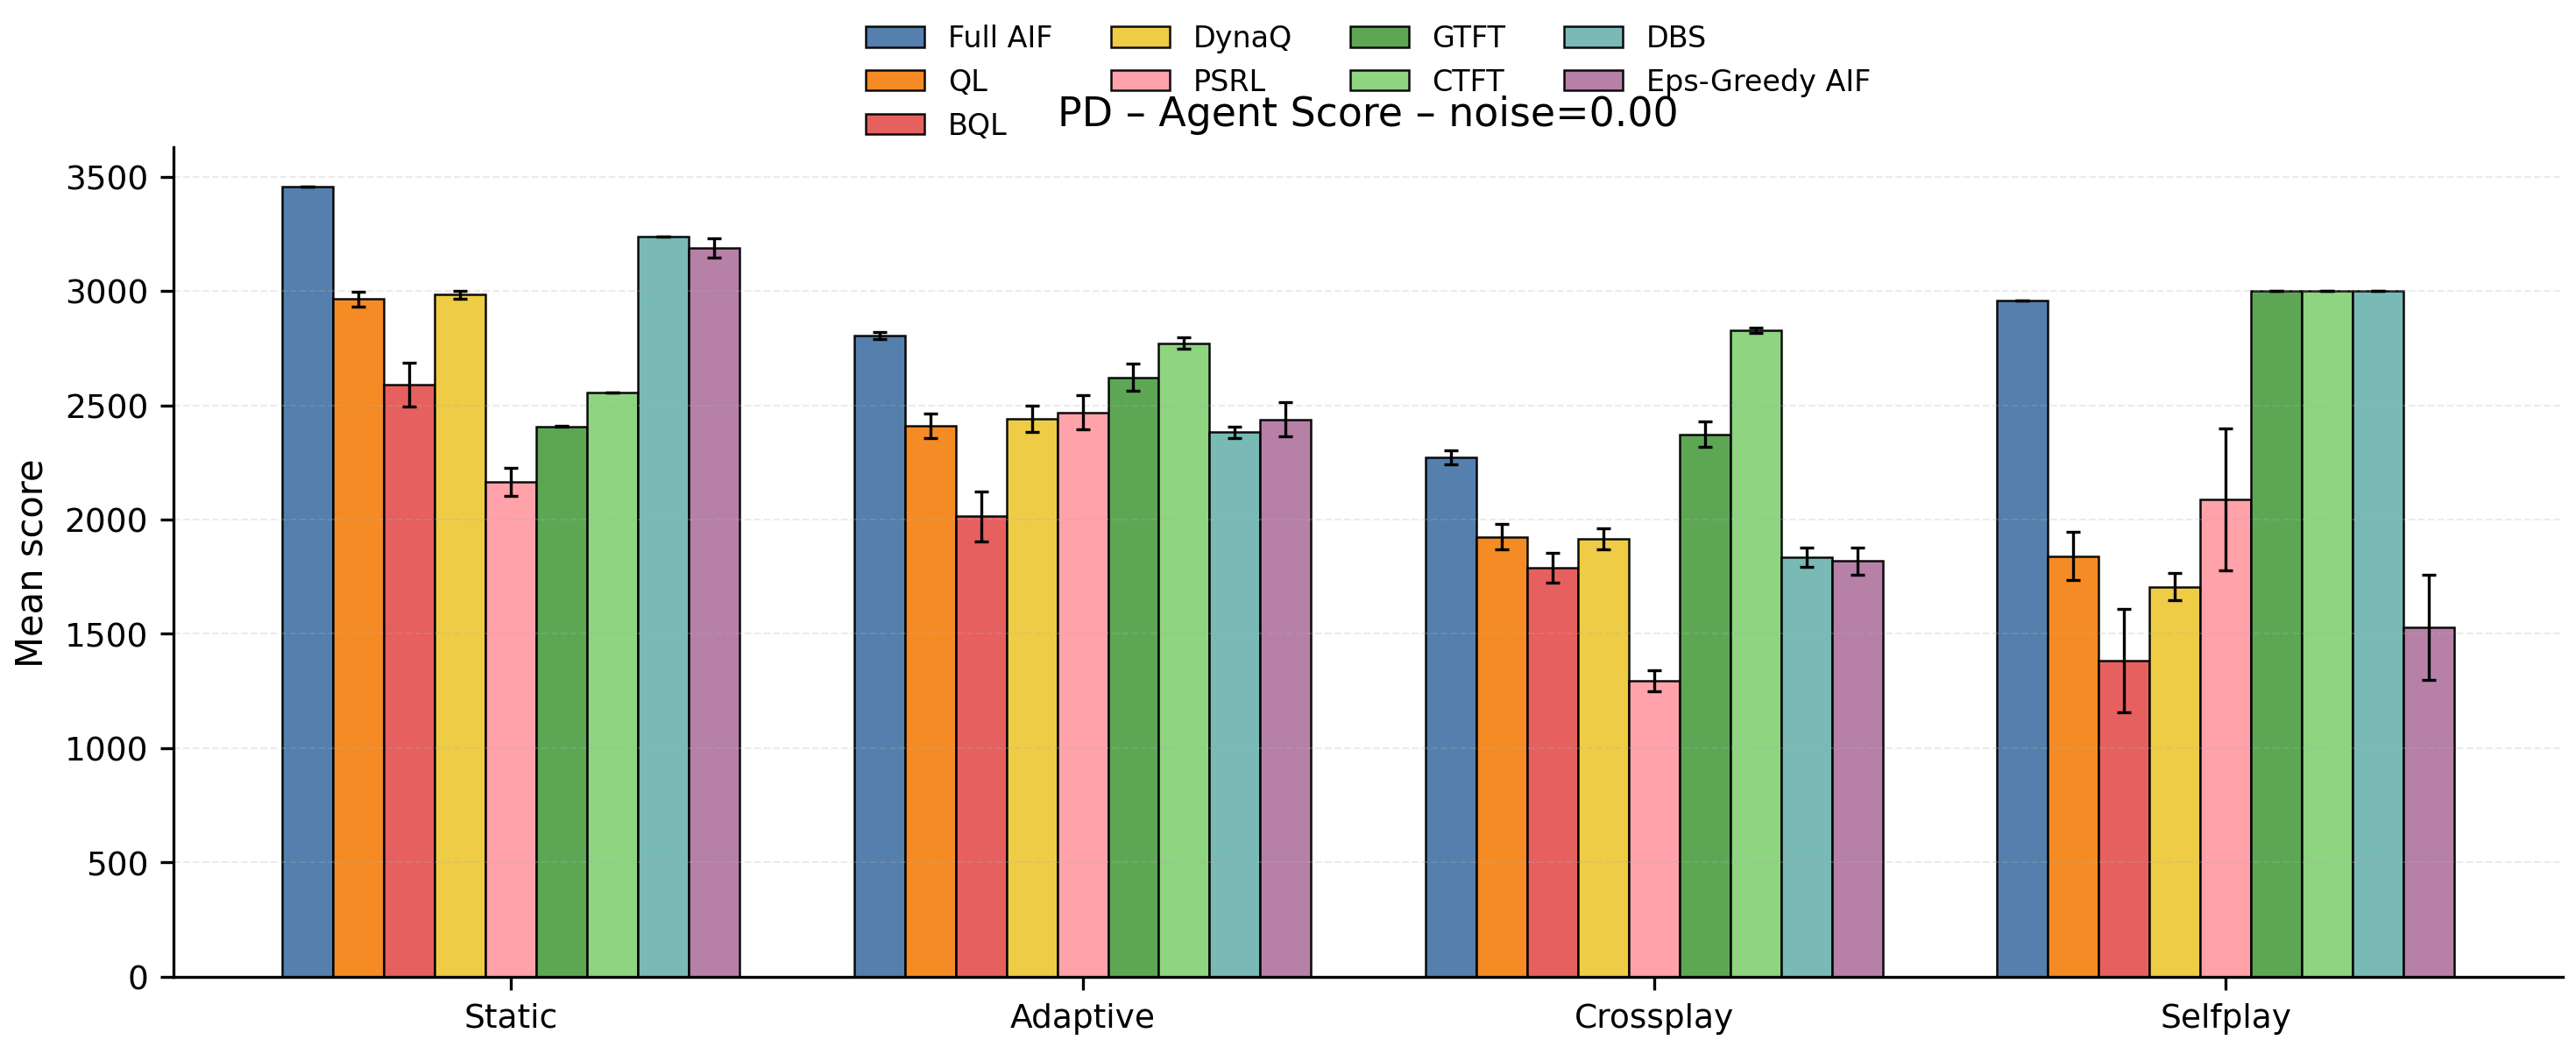

In [48]:
# Plot 1: Best AIF vs Best MARL vs Best Heuristic — Score @ noise 0.00
plot_bestof(noise=NOISE_LEVELS[0], metric="score")


Best-of winners  |  PD  |  Score  |  noise=0.05
Mode        AIF                           QL                            BQL                           DynaQ                         PSRL                          GTFT                          CTFT                          DBS                           EpsAIF                      
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Static      9_ActiveInferenceAgent  (3150.2639)  0_JaxQLearner  (2751.0250)    1_JaxBayesianQLearner  (2525.0917)  5_DynaQ  (2743.9000)          6_PSRL  (2555.1083)           3_GTFT  (2287.4139)           4_ContriteTitForTat  (2349.0083)  2_DBS  (3036.8444)            11_EpsilonGreedyAIFAgent  (2925.9806)
Adaptive    9_ActiveInferenceAgent  (2521.8694)  0_JaxQLearner  (2213.6194)    1_J

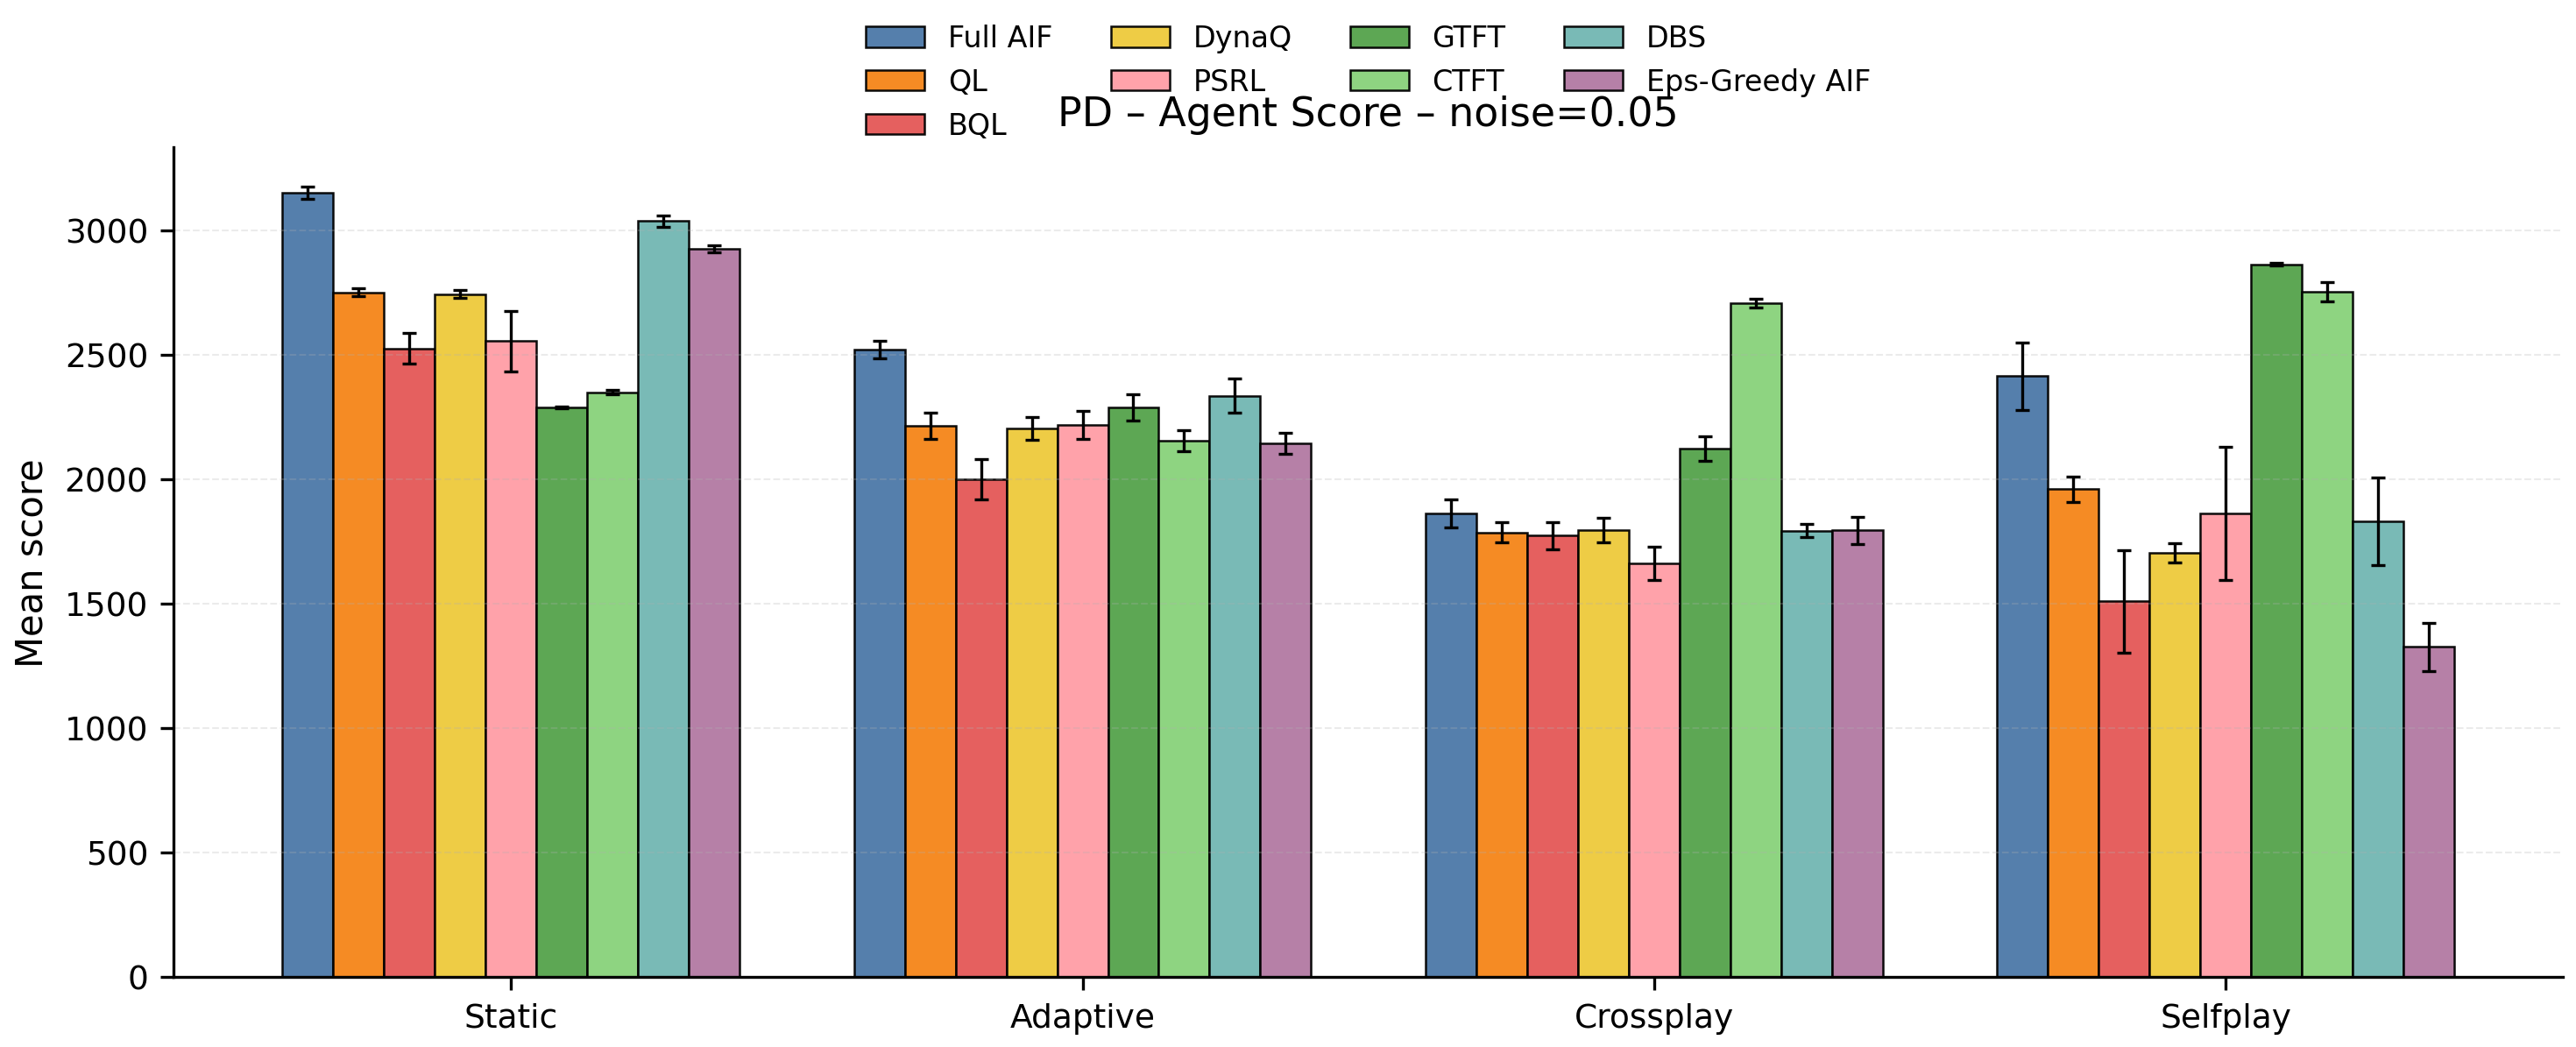

In [49]:
# Plot 2: Best AIF vs Best MARL vs Best Heuristic — Score @ noise 0.05
plot_bestof(noise=NOISE_LEVELS[1], metric="score")


Best-of winners  |  PD  |  CC rate  |  noise=0.00
Mode        AIF                           QL                            BQL                           DynaQ                         PSRL                          GTFT                          CTFT                          DBS                           EpsAIF                      
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Static      9_ActiveInferenceAgent  (0.3804)  0_JaxQLearner  (0.2873)       1_JaxBayesianQLearner  (0.2706)  5_DynaQ  (0.2496)             6_PSRL  (0.4032)              3_GTFT  (0.5990)              4_ContriteTitForTat  (0.4862)  2_DBS  (0.5011)               11_EpsilonGreedyAIFAgent  (0.1910)
Adaptive    9_ActiveInferenceAgent  (0.4706)  0_JaxQLearner  (0.4181)       1_JaxBayesianQLe

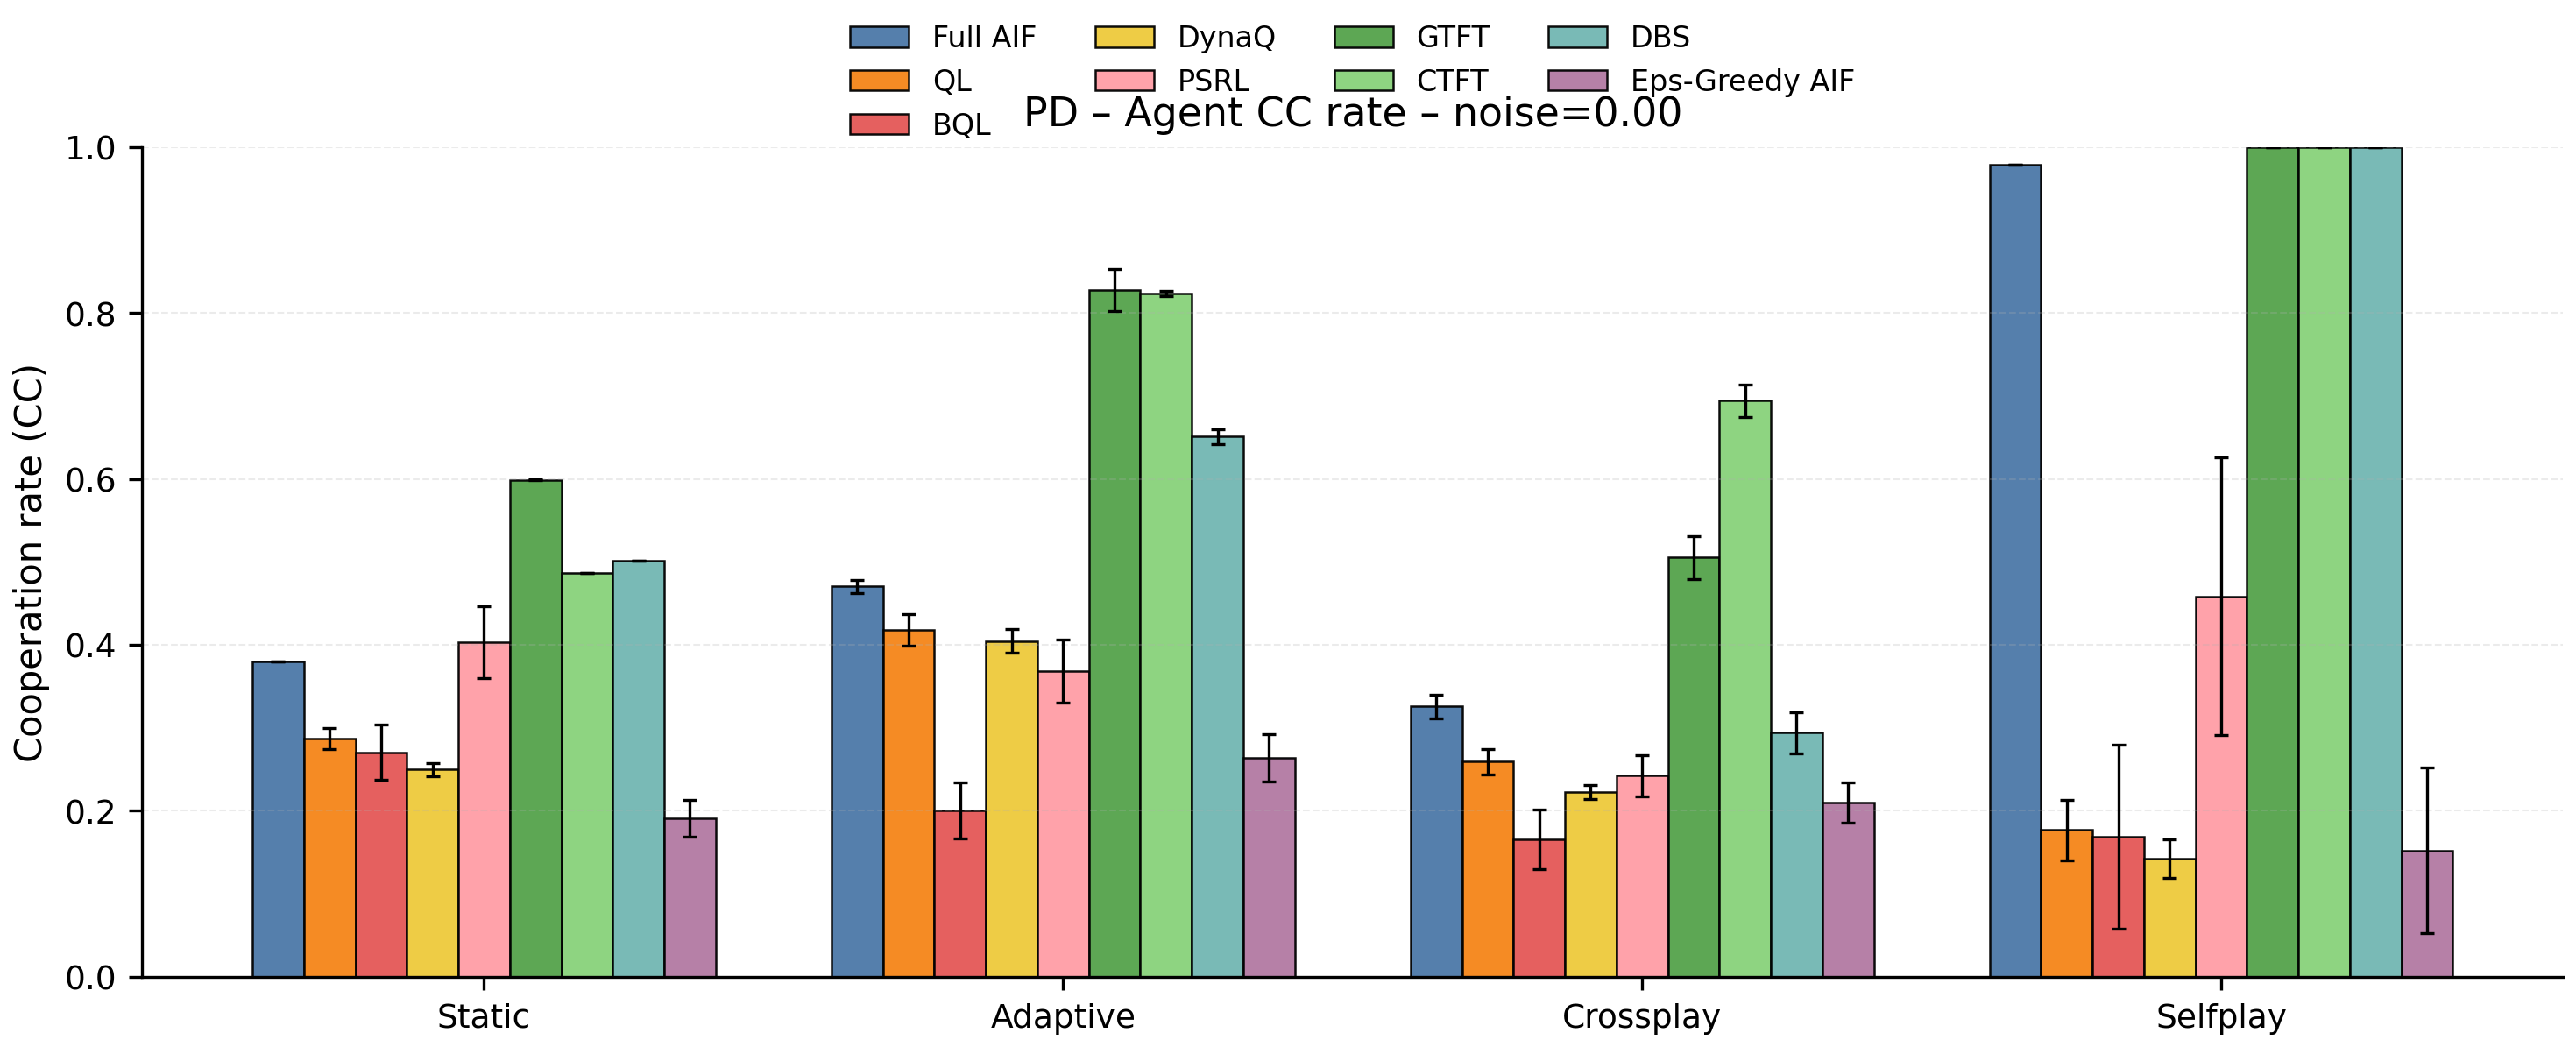

In [50]:
# Plot 3: Best AIF vs Best MARL vs Best Heuristic — CC rate @ noise 0.00
plot_bestof(noise=NOISE_LEVELS[0], metric="cc_rate")


Best-of winners  |  PD  |  CC rate  |  noise=0.05
Mode        AIF                           QL                            BQL                           DynaQ                         PSRL                          GTFT                          CTFT                          DBS                           EpsAIF                      
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Static      9_ActiveInferenceAgent  (0.2491)  0_JaxQLearner  (0.1903)       1_JaxBayesianQLearner  (0.2108)  5_DynaQ  (0.1870)             6_PSRL  (0.2774)              3_GTFT  (0.4611)              4_ContriteTitForTat  (0.3488)  2_DBS  (0.2630)               11_EpsilonGreedyAIFAgent  (0.1403)
Adaptive    9_ActiveInferenceAgent  (0.3533)  0_JaxQLearner  (0.2281)       1_JaxBayesianQLe

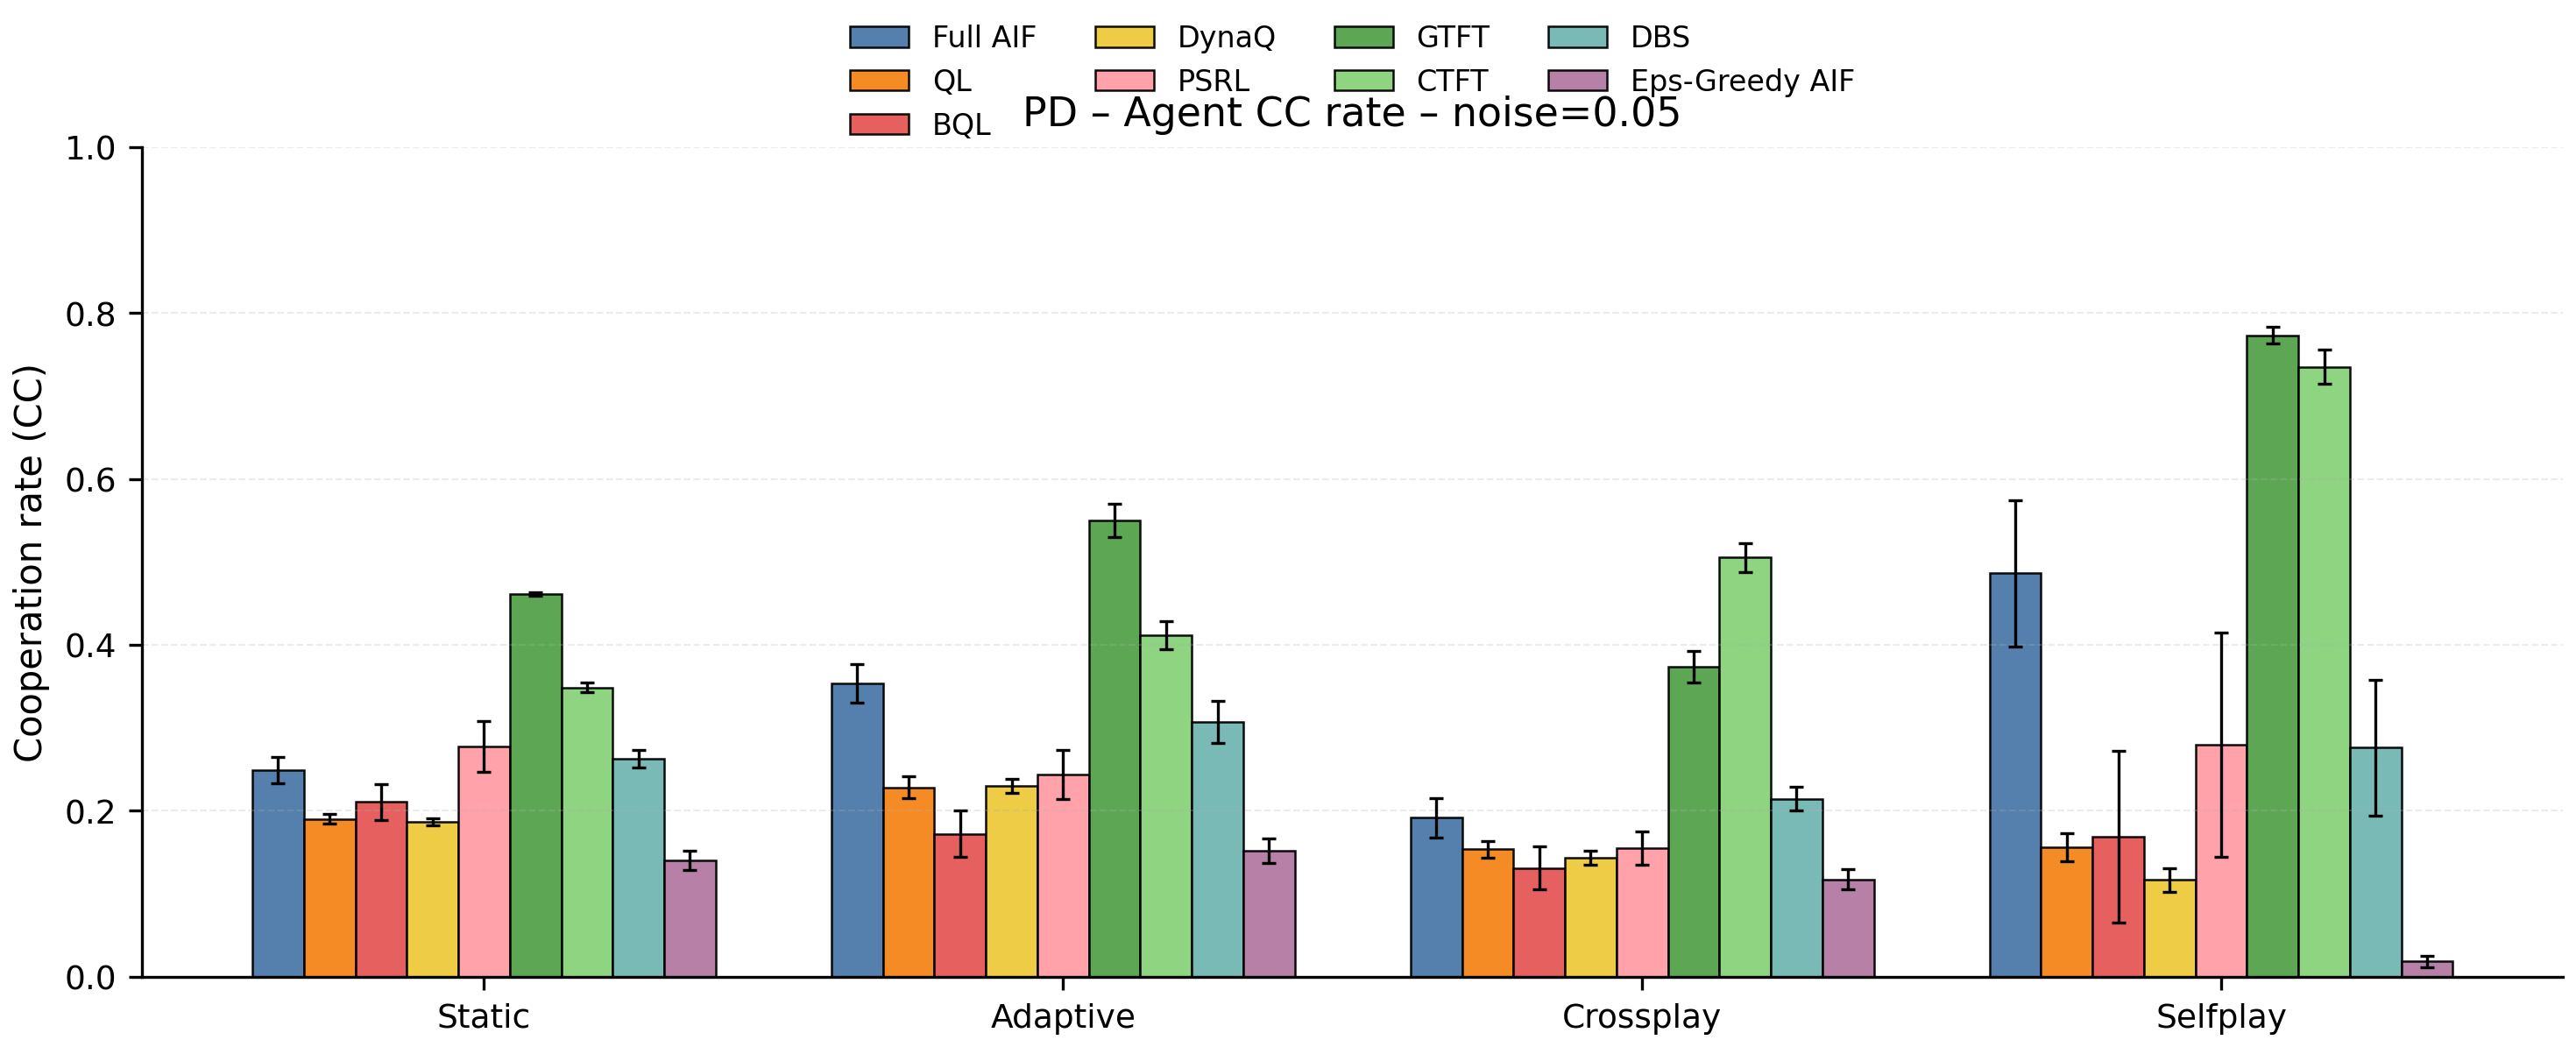

In [51]:
# Plot 4: Best AIF vs Best MARL vs Best Heuristic — CC rate @ noise 0.05
plot_bestof(noise=NOISE_LEVELS[1], metric="cc_rate")

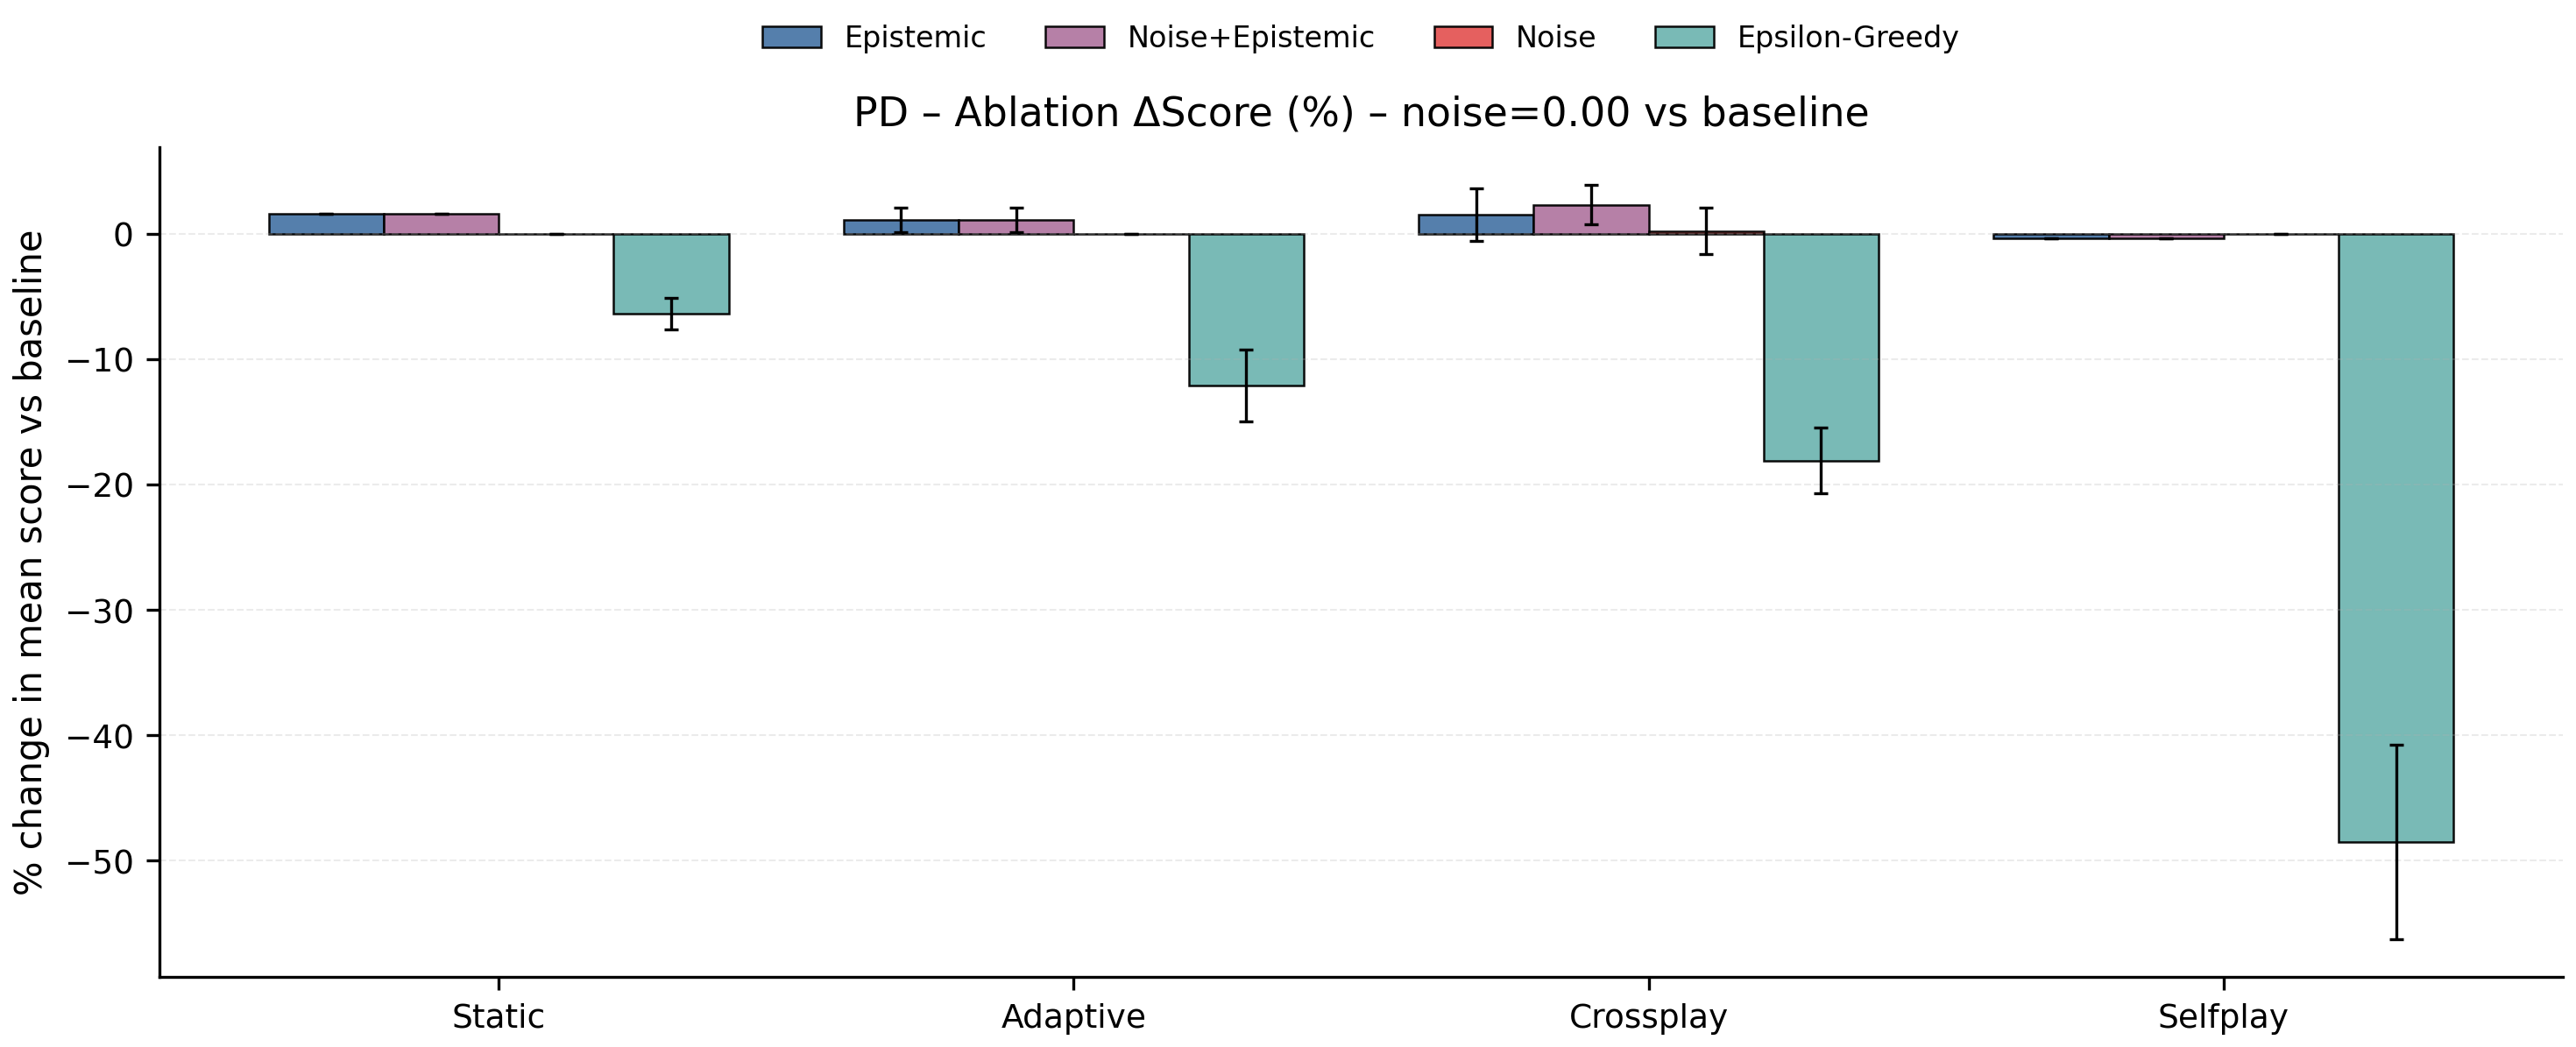

In [52]:
# Plot 5: Ablation % change vs base (8) — %ΔScore @ noise 0.00
plot_ablation_deltas(noise=NOISE_LEVELS[0], metric="score")

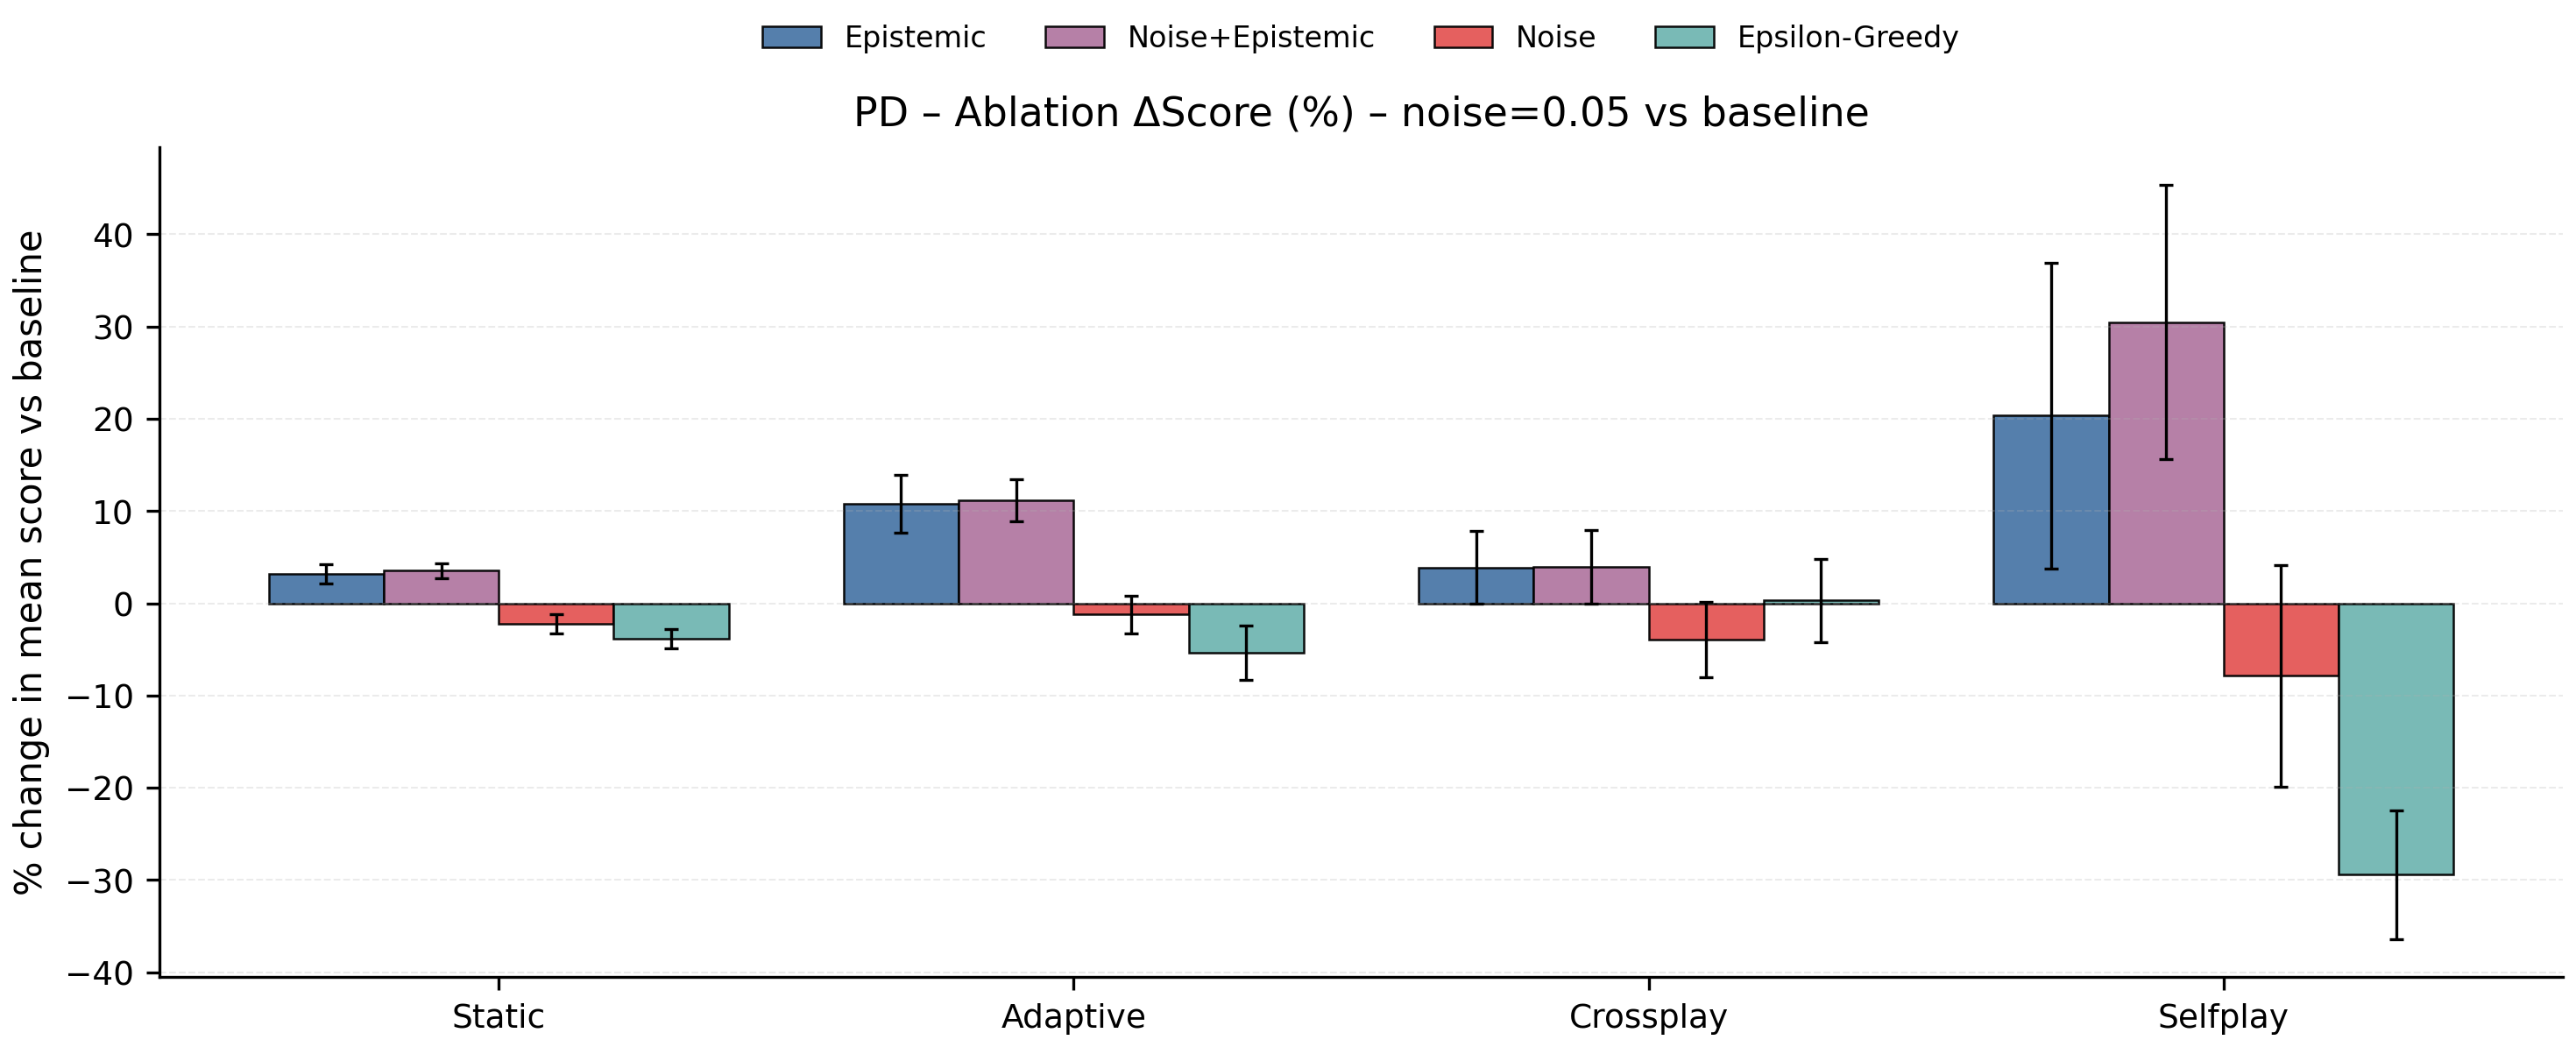

In [53]:
# Plot 6: Ablation % change vs base (8) — %ΔScore @ noise 0.05
plot_ablation_deltas(noise=NOISE_LEVELS[1], metric="score")

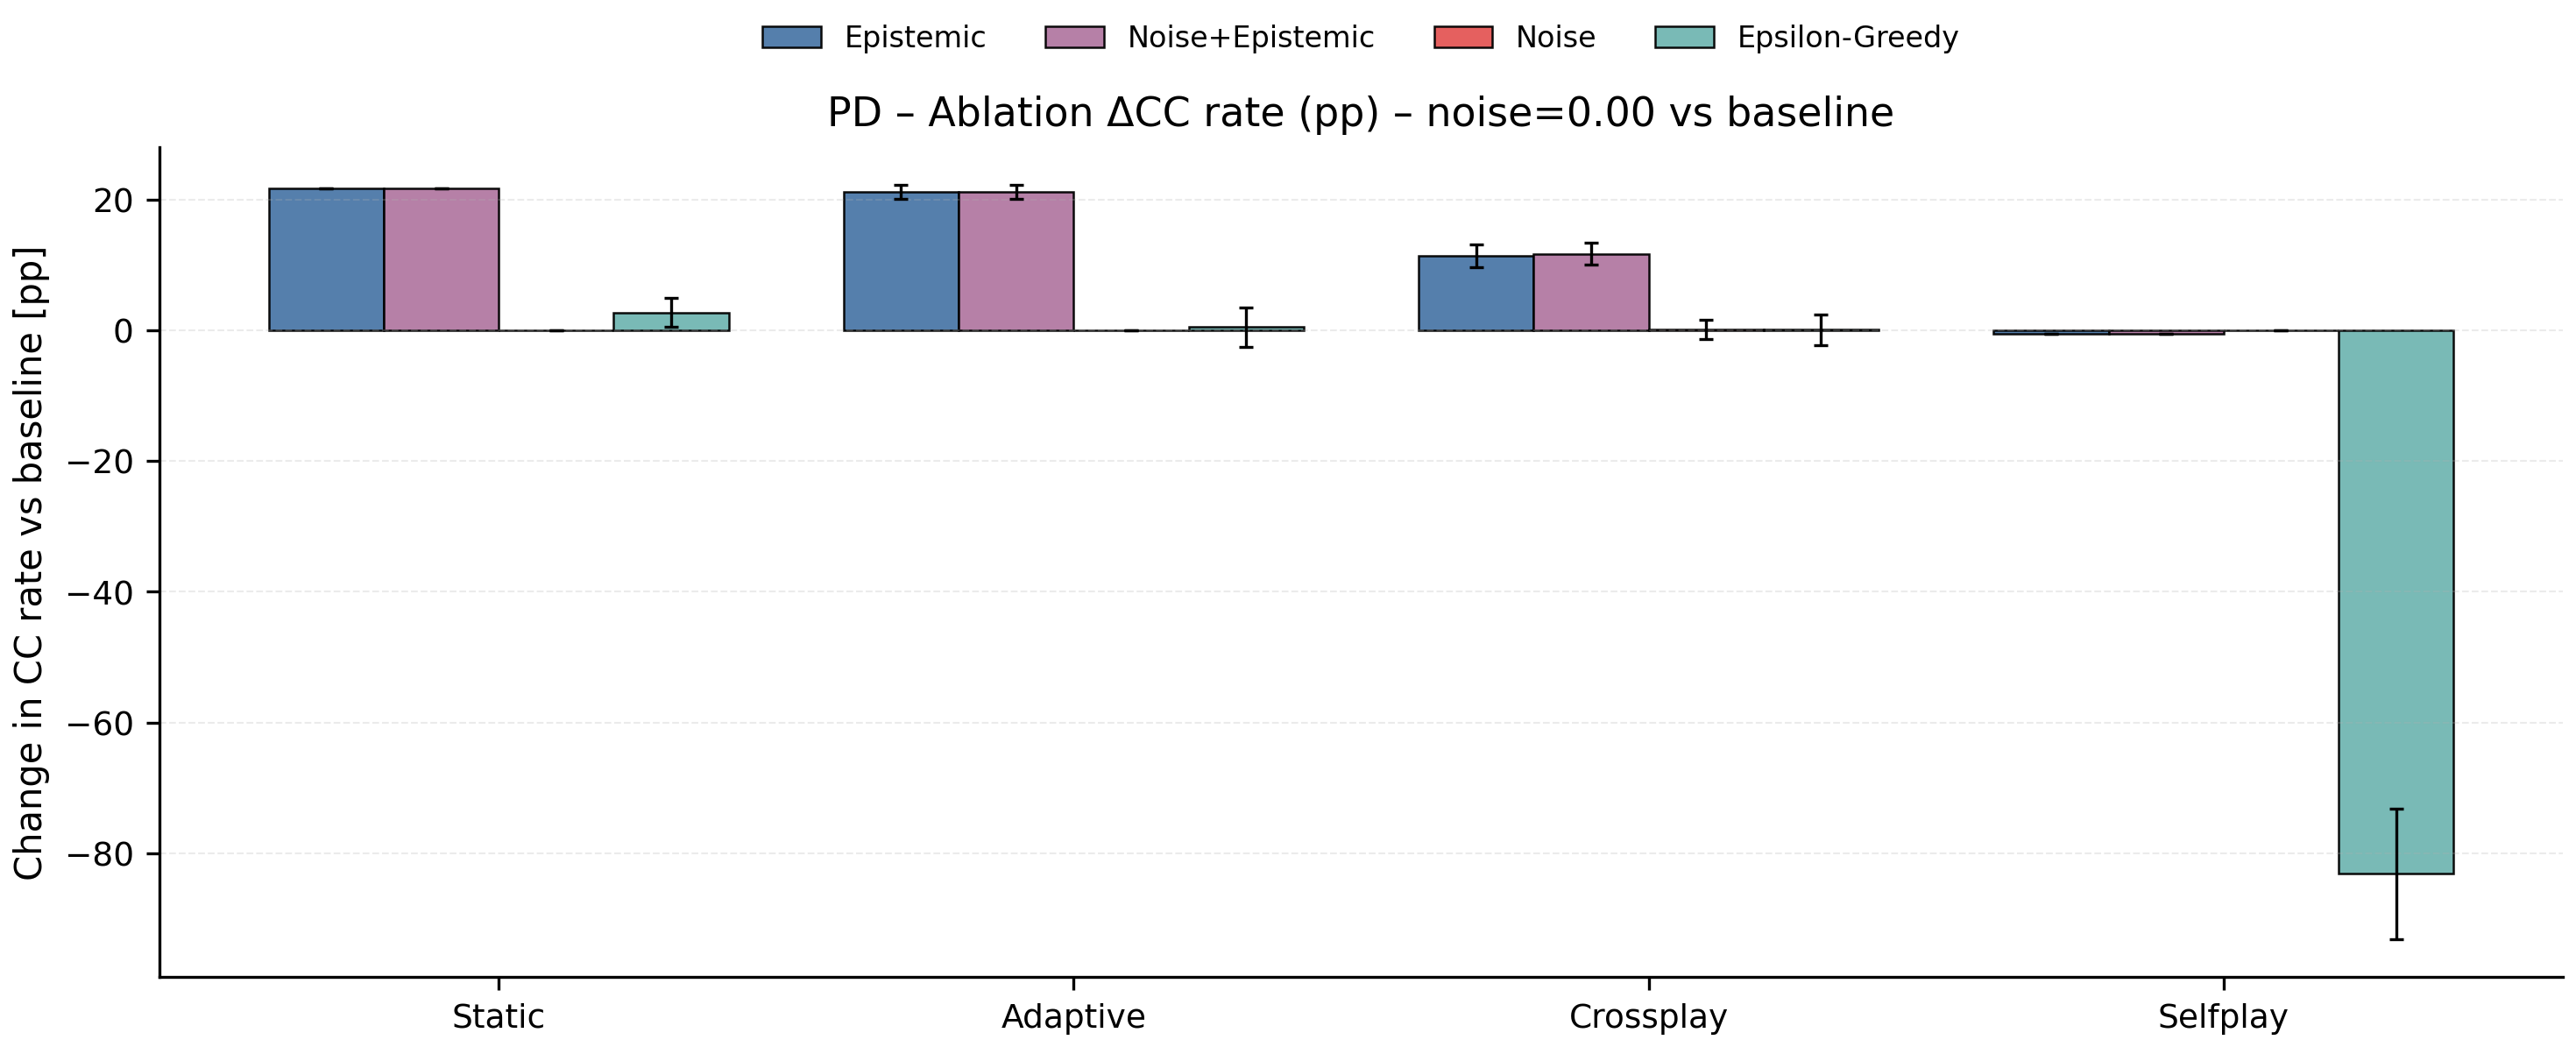

In [54]:
# Plot 7: Ablation % change vs base (8) — %ΔCC rate @ noise 0.00
plot_ablation_deltas(noise=NOISE_LEVELS[0], metric="cc_rate")

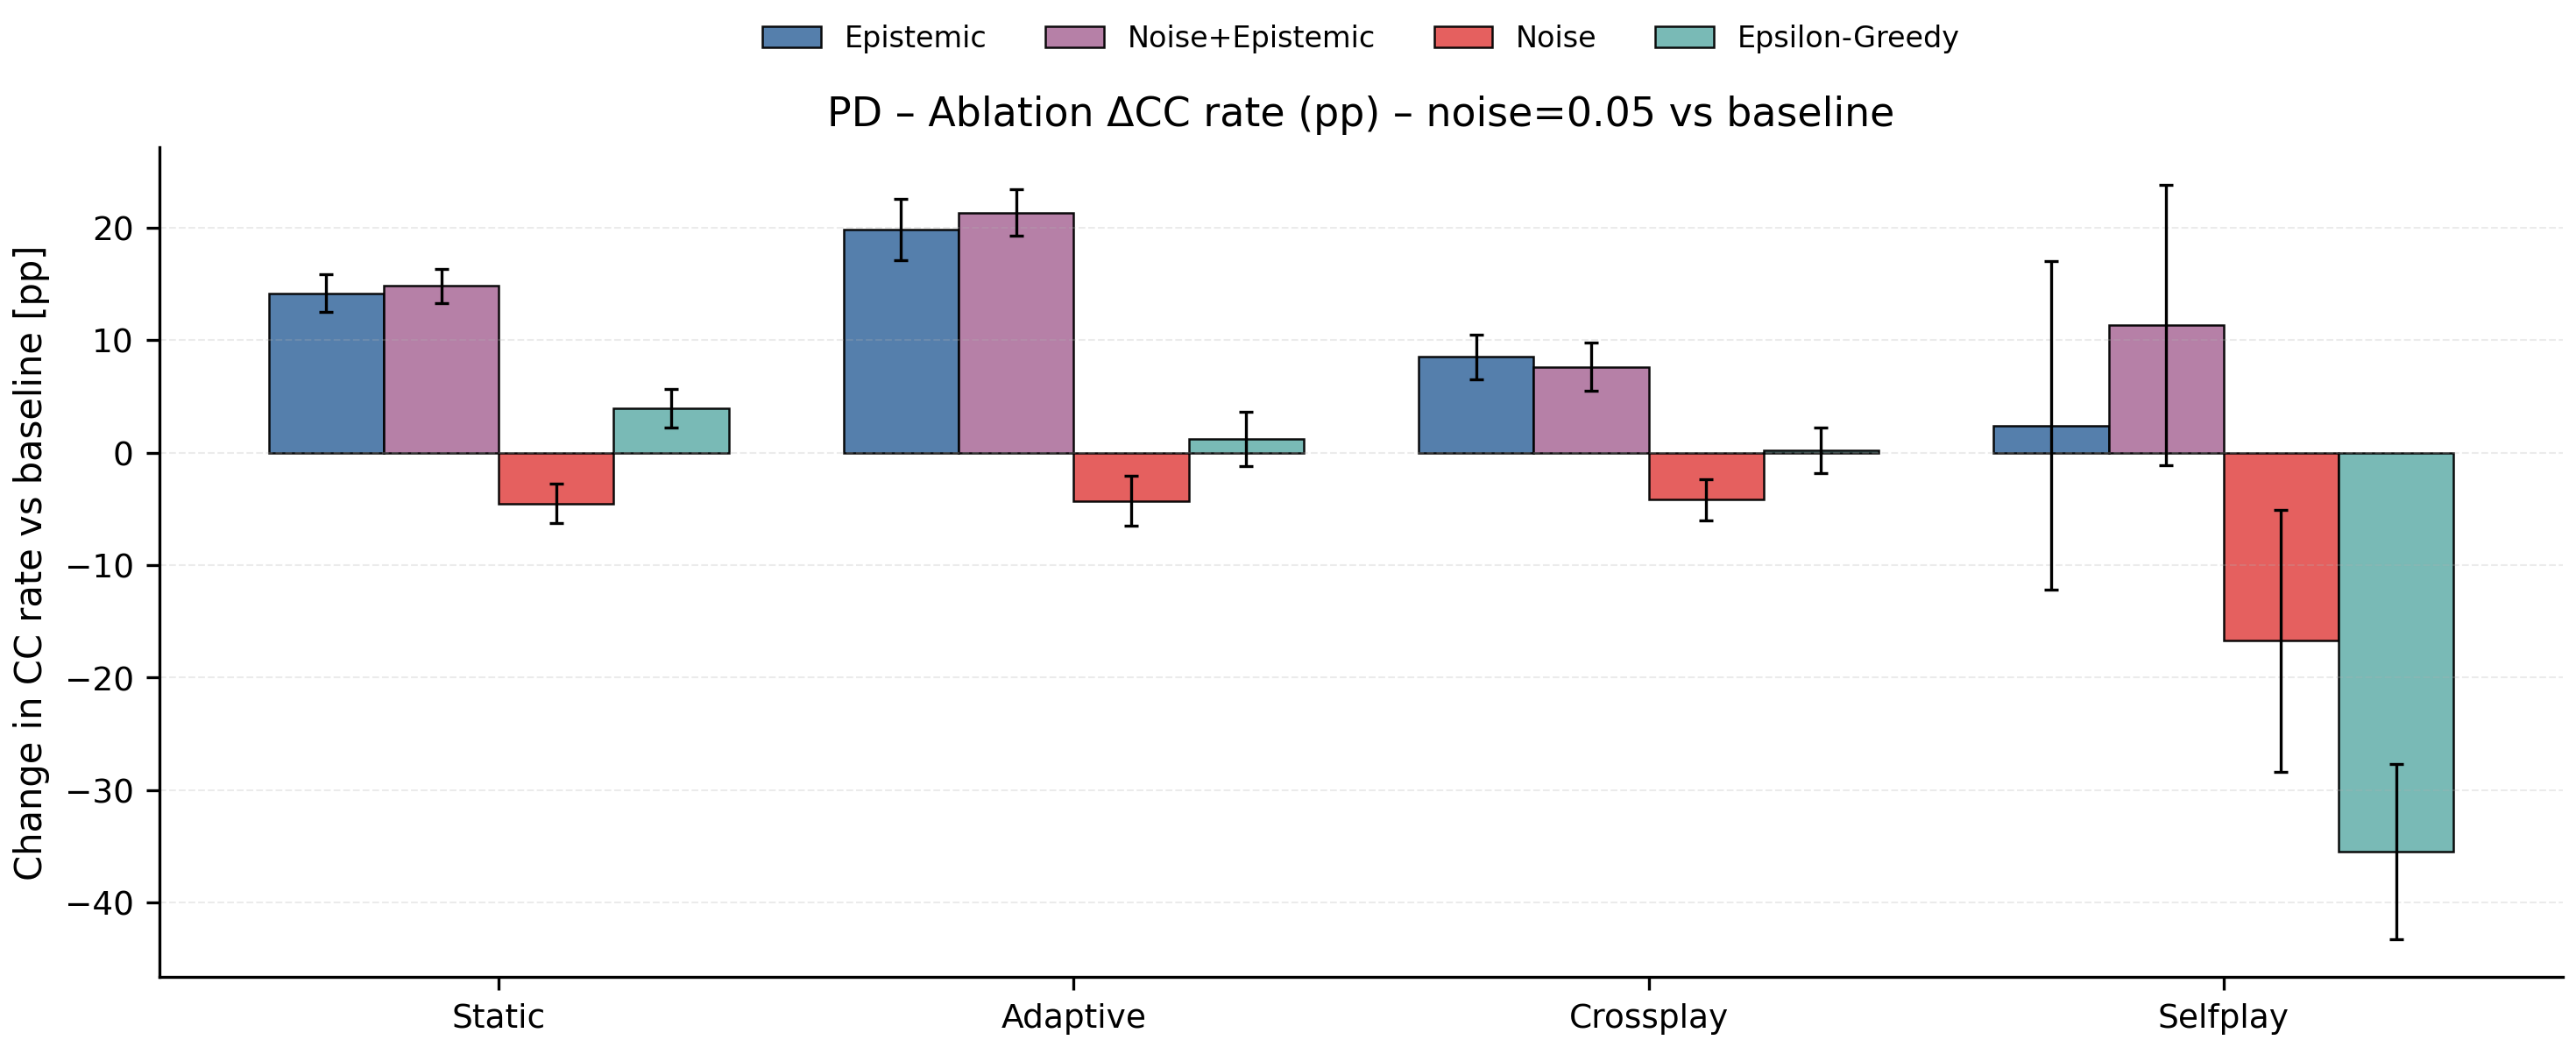

0.05

In [55]:
# Plot 8: Ablation % change vs base (8) — %ΔCC rate @ noise 0.05
plot_ablation_deltas(noise=NOISE_LEVELS[1], metric="cc_rate")
NOISE_LEVELS[1]

In [56]:
# Write the exact plotted values (means + 95% CI) to CSVs

def bestof_results_df(noise: float, metric: Literal["score", "cc_rate"]) -> pd.DataFrame:
    mode_aggs: dict[str, pd.DataFrame] = {}

    for mode in ["static", "adaptive"]:
        pool_dir = POOL_DIR_BY_MODE[mode]
        mode_aggs[mode] = _tournament_agg(pool_dir, noise, metric) if pool_dir.exists() else pd.DataFrame()

    if SP_DIR.exists():
        mode_aggs["crossplay"] = _selfplay_agg(SP_DIR, noise, metric, diagonal=False)
        mode_aggs["selfplay"] = _selfplay_agg(SP_DIR, noise, metric, diagonal=True)
    else:
        mode_aggs["crossplay"] = pd.DataFrame()
        mode_aggs["selfplay"] = pd.DataFrame()

    rows = []
    for mode in MODES:
        agg = mode_aggs.get(mode, pd.DataFrame())
        for group_name, agent_indices in GROUPS.items():
            best = _best_in_group(agg, agent_indices) if not agg.empty else {"agent_idx": None, "mean": np.nan, "ci_lower": np.nan, "ci_upper": np.nan, "n": 0}
            rows.append(
                {
                    "game": GAME,
                    "plot": "bestof",
                    "metric": metric,
                    "noise": noise,
                    "mode": mode,
                    "mode_label": MODE_LABEL[mode],
                    "group": group_name,
                    "best_agent_idx": best.get("agent_idx"),
                    "mean": best.get("mean"),
                    "ci_lower": best.get("ci_lower"),
                    "ci_upper": best.get("ci_upper"),
                    "n": best.get("n"),
                }
            )
    return pd.DataFrame(rows)


def ablation_results_df(noise: float, metric: Literal["score", "cc_rate"]) -> pd.DataFrame:
    # score → relative % change; cc_rate → percentage-point change
    _ci_fn = _paired_percent_change_ci if metric == "score" else _paired_pp_change_ci
    unit = "%" if metric == "score" else "pp"

    rows = []
    for mode in MODES:
        if mode in ["static", "adaptive"]:
            pool_dir = POOL_DIR_BY_MODE[mode]
            for label, a_idx, b_idx in ABLATIONS:
                if not pool_dir.exists():
                    mean = lo = hi = np.nan
                    n = 0
                else:
                    rep_var = _tournament_rep_values(pool_dir, a_idx, noise, metric)
                    rep_base = _tournament_rep_values(pool_dir, b_idx, noise, metric)
                    mean, lo, hi, n = _ci_fn(rep_var, rep_base)

                rows.append(
                    {
                        "game": GAME,
                        "metric": metric,
                        "unit": unit,
                        "noise": noise,
                        "mode": mode,
                        "mode_label": MODE_LABEL[mode],
                        "variant_label": label,
                        "variant_idx": a_idx,
                        "base_idx": b_idx,
                        "delta_mean": mean,
                        "delta_ci_lower": lo,
                        "delta_ci_upper": hi,
                        "n": n,
                    }
                )
        else:
            diagonal = mode == "selfplay"
            for label, a_idx, b_idx in ABLATIONS:
                if not SP_DIR.exists():
                    mean = lo = hi = np.nan
                    n = 0
                else:
                    rep_var = _selfplay_rep_values(SP_DIR, a_idx, noise, metric, diagonal=diagonal)
                    rep_base = _selfplay_rep_values(SP_DIR, b_idx, noise, metric, diagonal=diagonal)
                    mean, lo, hi, n = _ci_fn(rep_var, rep_base)

                rows.append(
                    {
                        "game": GAME,
                        "metric": metric,
                        "unit": unit,
                        "noise": noise,
                        "mode": mode,
                        "mode_label": MODE_LABEL[mode],
                        "variant_label": label,
                        "variant_idx": a_idx,
                        "base_idx": b_idx,
                        "delta_mean": mean,
                        "delta_ci_lower": lo,
                        "delta_ci_upper": hi,
                        "n": n,
                    }
                )

    return pd.DataFrame(rows)


# --- write all outputs ---
bestof_all = pd.concat(
    [bestof_results_df(noise=n, metric=m) for n in NOISE_LEVELS for m in ["score", "cc_rate"]],
    ignore_index=True,
)
ablations_all = pd.concat(
    [ablation_results_df(noise=n, metric=m) for n in NOISE_LEVELS for m in ["score", "cc_rate"]],
    ignore_index=True,
)

bestof_all.to_csv(OUTPUT_DIR / "proposal_bestof_results.csv", index=False)
ablations_all.to_csv(OUTPUT_DIR / "proposal_ablation_pct_change_results.csv", index=False)

print("Wrote:")
print(OUTPUT_DIR / "proposal_bestof_results.csv")
print(OUTPUT_DIR / "proposal_ablation_pct_change_results.csv")


Wrote:
../../results/main/pd/plots/proposal/proposal_bestof_results.csv
../../results/main/pd/plots/proposal/proposal_ablation_pct_change_results.csv
